# c30 - Final Batch GA Analysis

Comparison of 4 stock conditions from the final thesis GA runs:
- **Stock A** (reclaimed lot A + NS supplement, max_uses: RS=1, NS=10) — 6 runs
- **Stock B** (reclaimed lot B + NS supplement, max_uses: RS=1, NS=10) — 6 runs
- **New max=10** (NS only, max_uses=10) — 6 runs from batch
- **New max=120** (NS only, max_uses=120) — 3 runs outside batch

**Fitness is NOT cross-comparable** (normalized per stock). Use raw physical metrics for cross-condition comparison.

## 0. Configuration & Paths

In [29]:
import csv
import json
import importlib
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

import config
importlib.reload(config)

_PC  = config.PLOT_COLORS
_EXT = _PC["extra_colors"]

# ── Paths ──────────────────────────────────────────────────────────────────
BATCH_DIR = config.GA_DATA_PATH / 'GA_FINAL_BATCH_3PerStock_20260526_GEN250_EVAL_7500'

EXTRA_NEW_120_DIRS = [
    config.GA_DATA_PATH / 'GA_new_20260521_133441_RUN1_GEN250_EVAL7500_F0_6993',
    config.GA_DATA_PATH / 'GA_new_20260521_142053_RUN2_GEN250_EVAL7500_F0_7085',
    config.GA_DATA_PATH / 'GA_new_20260521_150903_RUN3_GEN250_EVAL7500_F0_7036',
]

OUTPUT_DIR = config.GA_DATA_PATH / 'c30_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Condition colours (consistent across all plots) ─────────────────────────
COND_ORDER  = ['Stock A', 'Stock B', 'New (max=10)', 'New (max=120)']
COND_COLORS = {
    'Stock A':       _PC["accent"],
    'Stock B':       _PC["danger"],
    'New (max=10)':  _PC["NS"],
    'New (max=120)': _EXT["deep_navy"],
}
SEED_MARKERS = {42: 'o', 43: 's', 44: '^'}

print('Batch dir:', BATCH_DIR)
print('Batch run dirs:', len(list(BATCH_DIR.iterdir())))
print('Extra New-120 dirs:', [d.name for d in EXTRA_NEW_120_DIRS])

Config System loaded successfully, Code running locally from thesis_generative_timber and Data is connected to OneDrive 2.2 - 2.4.

Batch dir: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\GA_FINAL_BATCH_3PerStock_20260526_GEN250_EVAL_7500
Batch run dirs: 18
Extra New-120 dirs: ['GA_new_20260521_133441_RUN1_GEN250_EVAL7500_F0_6993', 'GA_new_20260521_142053_RUN2_GEN250_EVAL7500_F0_7085', 'GA_new_20260521_150903_RUN3_GEN250_EVAL7500_F0_7036']


## 1. Data Loading

In [30]:
def parse_util_violations_rank1(filepath: Path) -> dict:
    """
    util_violations.csv is a ragged CSV: each row has a variable number of columns
    depending on how many members are over/under-stressed.
    Row structure: rank, count_above, [util_above × count_above], count_below, [util_below × count_below]
    util_above: sorted descending (worst first)
    util_below: sorted ascending (least used first, highest = closest to 100%)
    """
    with open(filepath, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)  # skip header — misaligned for ragged rows
        for row in reader:
            row = [v for v in row if v.strip() != '']
            if not row:
                continue
            rank = int(row[0])
            if rank != 1:
                continue
            count_above = int(row[1])
            util_above  = [float(v) for v in row[2 : 2 + count_above]]
            count_below = int(row[2 + count_above])
            util_below  = [float(v) for v in row[3 + count_above : 3 + count_above + count_below]]
            return {
                'count_above_1':  count_above,
                'sum_util_above': sum(util_above),
                'max_util_above': util_above[0]  if util_above else 0.0,
                'count_below_1':  count_below,
                'mean_util_safe': float(np.mean(util_below)) if util_below else 0.0,
                'max_util_safe':  util_below[-1] if util_below else 0.0,
            }
    return {k: np.nan for k in ['count_above_1','sum_util_above','max_util_above',
                                  'count_below_1','mean_util_safe','max_util_safe']}


def load_run(run_dir: Path) -> dict | None:
    stem = run_dir.name
    tk   = run_dir / 'top_k_designs'

    # ── Run config ────────────────────────────────────────────────────────
    cfg_file = run_dir / f'{stem}_run_config.json'
    if not cfg_file.exists():
        print(f'  SKIP (no config): {stem}')
        return None
    with open(cfg_file) as f:
        cfg = json.load(f)

    scenario      = cfg.get('scenario', cfg.get('ga_config', {}).get('scenario', 'unknown'))
    max_uses      = cfg.get('new_stock_max_uses', cfg.get('ga_config', {}).get('new_stock_max_uses', None))
    seed          = cfg.get('seed', cfg.get('ga_config', {}).get('seed', None))

    # ── Condition label ───────────────────────────────────────────────────
    if stem.startswith('GA_A'):
        condition = 'Stock A'
    elif stem.startswith('GA_B'):
        condition = 'Stock B'
    elif stem.startswith('GA_new') and max_uses == 120:
        condition = 'New (max=120)'
    elif stem.startswith('GA_new'):
        condition = 'New (max=10)'
    else:
        condition = 'Unknown'

    # ── Seed group (RUN number from stem) ────────────────────────────────
    import re
    m = re.search(r'RUN(\d+)', stem)
    run_num = int(m.group(1)) if m else -1

    # ── history.csv: gen-250 best_ever ───────────────────────────────────
    hist_file = run_dir / f'{stem}_history.csv'
    hist = pd.read_csv(hist_file)
    final_row = hist[hist['generation'] == hist['generation'].max()].iloc[0]
    best_fitness = float(final_row['best_ever'])

    # ── top10_summary.csv: rank-1 row ─────────────────────────────────────
    summary_file = tk / f'{stem}_top10_summary.csv'
    summary = pd.read_csv(summary_file)
    r1 = summary[summary['rank'] == 1].iloc[0]

    # ── util_violations: find file (Windows may have truncated name) ───────
    util_files = list(tk.glob('*util_violations*'))
    if not util_files:
        util_metrics = {k: np.nan for k in ['count_above_1','sum_util_above','max_util_above',
                                              'count_below_1','mean_util_safe','max_util_safe']}
        print(f'  WARN: no util_violations for {stem}')
    else:
        util_metrics = parse_util_violations_rank1(util_files[0])

    # ── top10_vertices.csv: geometry of rank-1 design ─────────────────────
    verts_file = tk / f'{stem}_top10_vertices.csv'
    verts = pd.read_csv(verts_file)
    verts = verts[verts['rank'] == 1].copy()
    verts[['x','y','z']] = verts[['x','y','z']].apply(pd.to_numeric, errors='coerce')
    top_v    = verts[verts['layer'] == 'top']
    bottom_v = verts[verts['layer'] == 'bottom']
    geom = {
        'n_vertices':    len(verts),
        'n_top':         len(top_v),
        'n_bottom':      len(bottom_v),
        'z_range':       float(verts['z'].max() - verts['z'].min()),
        'z_mean_top':    float(top_v['z'].mean()) if len(top_v) else np.nan,
        'z_mean_bottom': float(bottom_v['z'].mean()) if len(bottom_v) else np.nan,
        'xy_span_x':     float(verts['x'].max() - verts['x'].min()),
        'xy_span_y':     float(verts['y'].max() - verts['y'].min()),
    }

    # ── top10_edges_assigned.csv: RS_ vs NS_ counts ───────────────────────
    edges_file = tk / f'{stem}_top10_edges_assigned.csv'
    edges = pd.read_csv(edges_file)
    edges_r1 = edges[edges['rank'] == 1]
    n_reclaimed = int(edges_r1['assigned_timber'].str.startswith('RS_').sum())
    n_new_used  = int(edges_r1['assigned_timber'].str.startswith('NS_').sum())

    return {
        'stem':         stem,
        'condition':    condition,
        'run_num':      run_num,
        'seed':         seed,
        'max_uses':     max_uses,
        'scenario':     scenario,
        # fitness
        'best_fitness': best_fitness,
        # top10 rank-1 physical metrics
        'reuse_rate':          float(r1['reuse_rate']),
        'total_cost':          float(r1['total_cost']),
        'waste_total':         float(r1['waste_total']),
        'gnn_feasibility':     float(r1['gnn_feasibility']),
        'n_unsafe_members':    int(r1['n_unsafe_members']),
        'generation_found':    int(r1['generation']),
        # util violations
        **util_metrics,
        # geometry
        **geom,
        # edge assignment
        'n_reclaimed_used': n_reclaimed,
        'n_new_used':       n_new_used,
        # raw history for convergence plots (stored separately)
        '_history': hist,
        '_verts':   verts,
    }


In [31]:
run_dirs_batch = sorted([d for d in BATCH_DIR.iterdir() if d.is_dir()])
all_dirs = run_dirs_batch + EXTRA_NEW_120_DIRS

records   = []
histories = {}  # stem -> DataFrame
vertices  = {}  # stem -> DataFrame (rank-1 only)

for d in all_dirs:
    print(f'Loading {d.name} ...')
    rec = load_run(d)
    if rec is None:
        continue
    histories[rec['stem']] = rec.pop('_history')
    vertices[rec['stem']]  = rec.pop('_verts')
    records.append(rec)

df = pd.DataFrame(records)
df['condition'] = pd.Categorical(df['condition'], categories=COND_ORDER, ordered=True)
df = df.sort_values(['condition', 'run_num', 'best_fitness']).reset_index(drop=True)

print(f'\nLoaded {len(df)} runs:')
print(df.groupby('condition', observed=True)['stem'].count())

Loading GA_A_20260520_214255_RUN1_GEN250_EVAL7500_F-0_4778 ...
Loading GA_A_20260520_214422_RUN1_GEN250_EVAL7500_F-0_4852 ...
Loading GA_A_20260520_233847_RUN2_GEN250_EVAL7500_F-0_4720 ...
Loading GA_A_20260520_233940_RUN2_GEN250_EVAL7500_F-0_4759 ...
Loading GA_A_20260521_013727_RUN3_GEN250_EVAL7500_F-0_4822 ...
Loading GA_A_20260521_013811_RUN3_GEN250_EVAL7500_F-0_4843 ...
Loading GA_B_20260521_033812_RUN4_GEN250_EVAL7500_F-0_3334 ...
Loading GA_B_20260521_033916_RUN4_GEN250_EVAL7500_F-0_2475 ...
Loading GA_B_20260521_053429_RUN5_GEN250_EVAL7500_F-0_2759 ...
Loading GA_B_20260521_053555_RUN5_GEN250_EVAL7500_F-0_2499 ...
Loading GA_B_20260521_073733_RUN6_GEN250_EVAL7500_F-0_3634 ...
Loading GA_B_20260521_073848_RUN6_GEN250_EVAL7500_F-0_2340 ...
Loading GA_new_20260521_091521_RUN7_GEN250_EVAL7500_F0_6986 ...
Loading GA_new_20260521_091557_RUN7_GEN250_EVAL7500_F0_6973 ...
Loading GA_new_20260521_104859_RUN8_GEN250_EVAL7500_F0_7038 ...
Loading GA_new_20260521_104917_RUN8_GEN250_EVAL7500_

## 2. Replicate Handling — Best per Seed

In [32]:
# For each (condition, run_num) pair: keep the run with the lower fitness (lower = better always)
df_best = (
    df.sort_values('best_fitness')
      .groupby(['condition', 'run_num'], observed=True)
      .first()
      .reset_index()
)
df_best['condition'] = pd.Categorical(df_best['condition'], categories=COND_ORDER, ordered=True)

print('df_all  rows:', len(df))
print('df_best rows:', len(df_best))
print()
print('Best fitness per condition (df_best):')
print(df_best.groupby('condition', observed=True)['best_fitness'].agg(['mean','std','min','max']).round(4))

df_all  rows: 21
df_best rows: 12

Best fitness per condition (df_best):
                 mean     std     min     max
condition                                    
Stock A       -0.4818  0.0051 -0.4852 -0.4759
Stock B       -0.3242  0.0445 -0.3634 -0.2759
New (max=10)   0.7019  0.0040  0.6973  0.7047
New (max=120)  0.7038  0.0046  0.6993  0.7085


## 3. Aggregation Table

In [33]:
COMPARE_METRICS = [
    'best_fitness',
    'reuse_rate',
    'total_cost',
    'waste_total',
    'gnn_feasibility',
    'n_unsafe_members',
    'count_above_1',
    'sum_util_above',
    'mean_util_safe',
    'max_util_safe',
    'z_range',
    'n_reclaimed_used',
]

def agg_condition(df_in):
    rows = []
    for cond, grp in df_in.groupby('condition', observed=True):
        row = {'condition': cond, 'n_runs': len(grp)}
        for m in COMPARE_METRICS:
            if m not in grp.columns:
                continue
            vals = grp[m].dropna()
            row[f'{m}_mean'] = vals.mean()
            row[f'{m}_std']  = vals.std()
            row[f'{m}_min']  = vals.min()
            row[f'{m}_max']  = vals.max()
        rows.append(row)
    return pd.DataFrame(rows).set_index('condition')

df_agg_all  = agg_condition(df)
df_agg_best = agg_condition(df_best)

# Pretty-print key columns
show_cols = ['reuse_rate_mean','reuse_rate_std',
             'total_cost_mean','total_cost_std',
             'count_above_1_mean','count_above_1_std',
             'gnn_feasibility_mean','gnn_feasibility_std',
             'z_range_mean','z_range_std']
print('── Aggregated (all replicates) ──')
display(df_agg_all[show_cols].round(4))
print('\n── Aggregated (best per seed) ──')
display(df_agg_best[show_cols].round(4))

── Aggregated (all replicates) ──


,reuse_rate_mean,reuse_rate_std,total_cost_mean,total_cost_std,count_above_1_mean,count_above_1_std,gnn_feasibility_mean,gnn_feasibility_std,z_range_mean,z_range_std
condition,,,,,,,,,,
Stock A,0.7407,0.0112,129.3015,1.4116,8.0000,12.4258,0.7565,0.0058,2.5793,0.0752
Stock B,0.8061,0.0702,143.0547,5.4210,12.6667,19.6231,0.7578,0.0137,2.6247,0.0008
New (max=10),0.0000,0.0000,195.7233,2.5659,19.1667,16.6423,0.7384,0.0050,2.1820,0.1582
New (max=120),0.0000,0.0000,198.1683,4.5417,12.0000,20.7846,0.7455,0.0084,2.3947,0.2988



── Aggregated (best per seed) ──


,reuse_rate_mean,reuse_rate_std,total_cost_mean,total_cost_std,count_above_1_mean,count_above_1_std,gnn_feasibility_mean,gnn_feasibility_std,z_range_mean,z_range_std
condition,,,,,,,,,,
Stock A,0.7401,0.009,129.1360,1.5887,12.6667,17.7858,0.7584,0.0024,2.5413,0.0981
Stock B,0.8599,0.060,146.0442,5.7940,0.0000,0.0000,0.7482,0.0131,2.6243,0.0012
New (max=10),0.0000,0.000,193.8745,1.8467,23.6667,17.0392,0.7341,0.0012,2.0837,0.0645
New (max=120),0.0000,0.000,198.1683,4.5417,12.0000,20.7846,0.7455,0.0084,2.3947,0.2988


## 4. Convergence Plots

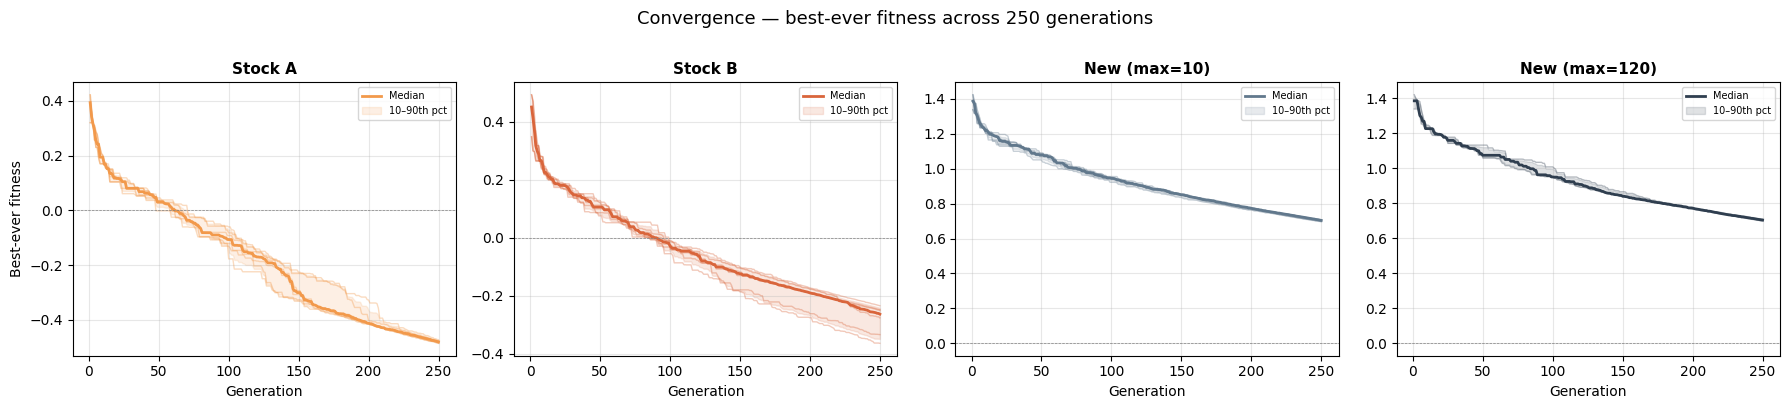

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for ax, cond in zip(axes, COND_ORDER):
    runs_in_cond = df[df['condition'] == cond]
    color = COND_COLORS[cond]
    all_best_ever = []

    for _, row in runs_in_cond.iterrows():
        hist = histories[row['stem']]
        gens  = hist['generation'].values
        be    = hist['best_ever'].values
        all_best_ever.append(be)
        mkr = SEED_MARKERS.get(row['seed'], 'o')
        ax.plot(gens, be, alpha=0.35, lw=1.0, color=color)

    # Median + IQR band across all runs in condition
    if all_best_ever:
        mat = np.array(all_best_ever)  # shape (n_runs, n_gen)
        median = np.median(mat, axis=0)
        p10    = np.percentile(mat, 10, axis=0)
        p90    = np.percentile(mat, 90, axis=0)
        ax.plot(gens, median, lw=2.0, color=color, label='Median')
        ax.fill_between(gens, p10, p90, alpha=0.15, color=color, label='10–90th pct')

    ax.set_title(cond, fontsize=11, fontweight='bold')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Best-ever fitness' if ax == axes[0] else '')
    ax.axhline(0, color='grey', lw=0.5, linestyle='--')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Convergence — best-ever fitness across 250 generations', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Condition Metric Box Plots

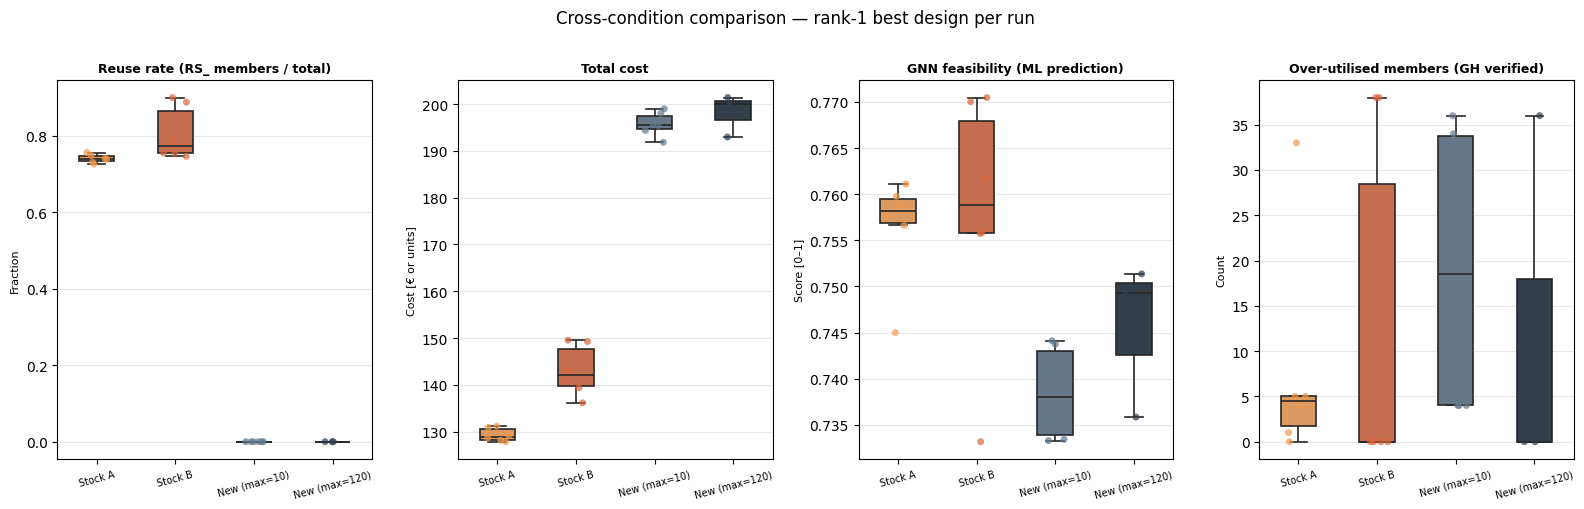

In [35]:
BOXPLOT_METRICS = [
    ('reuse_rate',      'Reuse rate (RS_ members / total)',  'Fraction'),
    ('total_cost',      'Total cost',                        'Cost [€ or units]'),
    ('gnn_feasibility', 'GNN feasibility (ML prediction)',   'Score [0–1]'),
    ('count_above_1',   'Over-utilised members (GH verified)','Count'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, title, ylabel) in zip(axes, BOXPLOT_METRICS):
    # Box + individual points per condition
    sns.boxplot(
        data=df, x='condition', y=metric,
        palette=COND_COLORS, order=COND_ORDER,
        width=0.45, linewidth=1.2, fliersize=0, ax=ax
    )
    sns.stripplot(
        data=df, x='condition', y=metric,
        palette=COND_COLORS, order=COND_ORDER,
        size=5, jitter=0.15, alpha=0.7, ax=ax
    )
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=15)
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Cross-condition comparison — rank-1 best design per run', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Utilisation Analysis

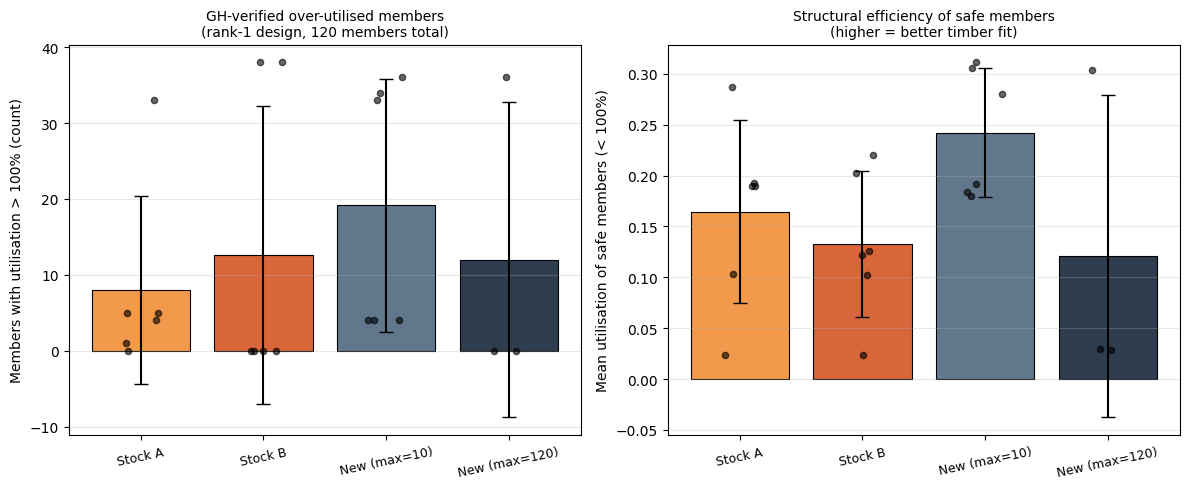

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 6a. Over-utilised member count ────────────────────────────────────────
ax = axes[0]
agg = df.groupby('condition', observed=True)['count_above_1'].agg(['mean','std']).reindex(COND_ORDER)
x = np.arange(len(COND_ORDER))
bars = ax.bar(x, agg['mean'], yerr=agg['std'], capsize=5,
              color=[COND_COLORS[c] for c in COND_ORDER], edgecolor='black', linewidth=0.8)
# overlay individual points
for i, cond in enumerate(COND_ORDER):
    vals = df[df['condition'] == cond]['count_above_1'].dropna()
    ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.15, 0.15, len(vals)),
               vals, color='black', s=20, zorder=5, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(COND_ORDER, rotation=12, fontsize=9)
ax.set_ylabel('Members with utilisation > 100% (count)')
ax.set_title('GH-verified over-utilised members\n(rank-1 design, 120 members total)', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# ── 6b. Mean safe-member utilisation ──────────────────────────────────────
ax = axes[1]
agg2 = df.groupby('condition', observed=True)['mean_util_safe'].agg(['mean','std']).reindex(COND_ORDER)
ax.bar(x, agg2['mean'], yerr=agg2['std'], capsize=5,
       color=[COND_COLORS[c] for c in COND_ORDER], edgecolor='black', linewidth=0.8)
for i, cond in enumerate(COND_ORDER):
    vals = df[df['condition'] == cond]['mean_util_safe'].dropna()
    ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.15, 0.15, len(vals)),
               vals, color='black', s=20, zorder=5, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(COND_ORDER, rotation=12, fontsize=9)
ax.set_ylabel('Mean utilisation of safe members (< 100%)')
ax.set_title('Structural efficiency of safe members\n(higher = better timber fit)', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_utilisation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Geometry Comparison

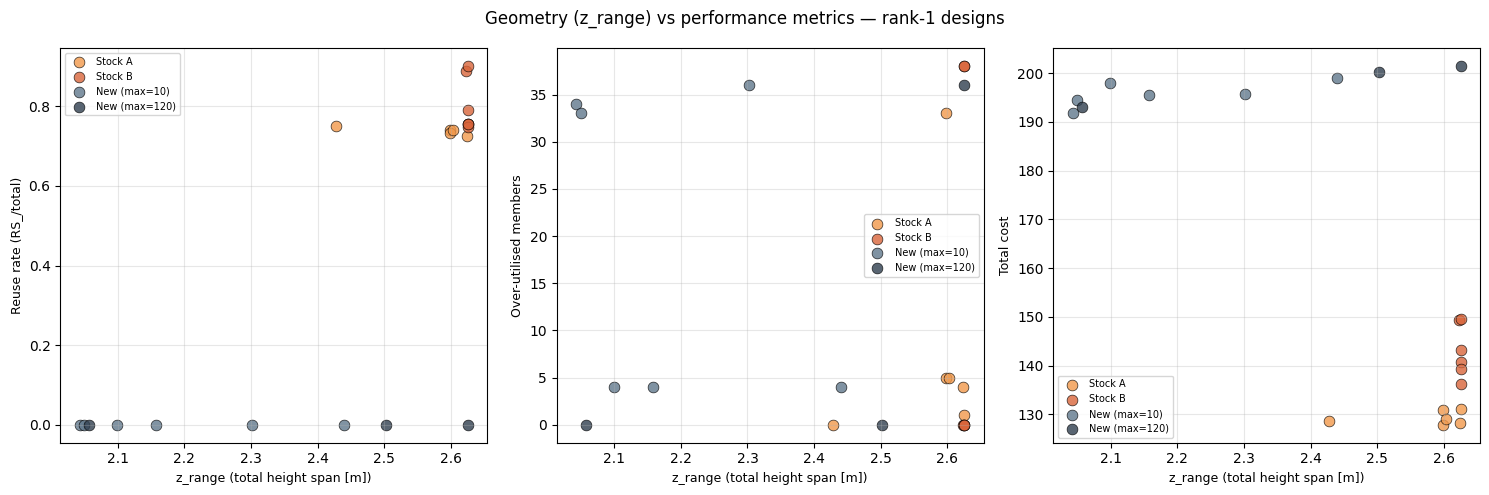

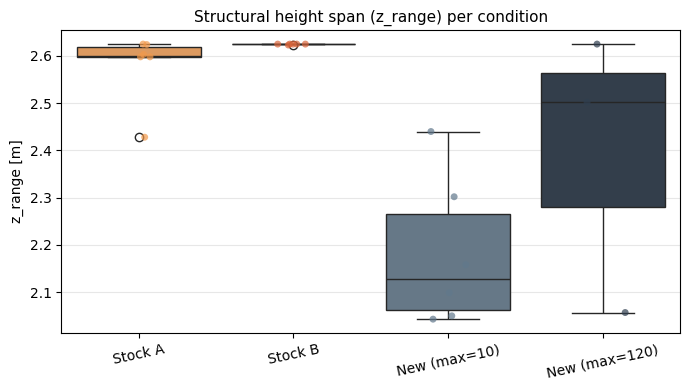

In [37]:
# ── 7a. z_range scatter vs reuse_rate and count_above_1 ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_pairs = [
    ('z_range', 'reuse_rate',      'Reuse rate (RS_/total)'),
    ('z_range', 'count_above_1',   'Over-utilised members'),
    ('z_range', 'total_cost',      'Total cost'),
]

for ax, (xcol, ycol, ylabel) in zip(axes, scatter_pairs):
    for cond in COND_ORDER:
        sub = df[df['condition'] == cond]
        ax.scatter(sub[xcol], sub[ycol], label=cond,
                   color=COND_COLORS[cond], s=60, alpha=0.8, edgecolors='black', linewidths=0.5)
    ax.set_xlabel('z_range (total height span [m])', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Geometry (z_range) vs performance metrics — rank-1 designs', fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_geometry_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7b. z_range box per condition ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='condition', y='z_range', palette=COND_COLORS, order=COND_ORDER, ax=ax)
sns.stripplot(data=df, x='condition', y='z_range', palette=COND_COLORS, order=COND_ORDER,
              size=5, jitter=0.15, alpha=0.7, ax=ax)
ax.set_title('Structural height span (z_range) per condition', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('z_range [m]')
ax.tick_params(axis='x', rotation=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_zrange_box.png', dpi=150, bbox_inches='tight')
plt.show()

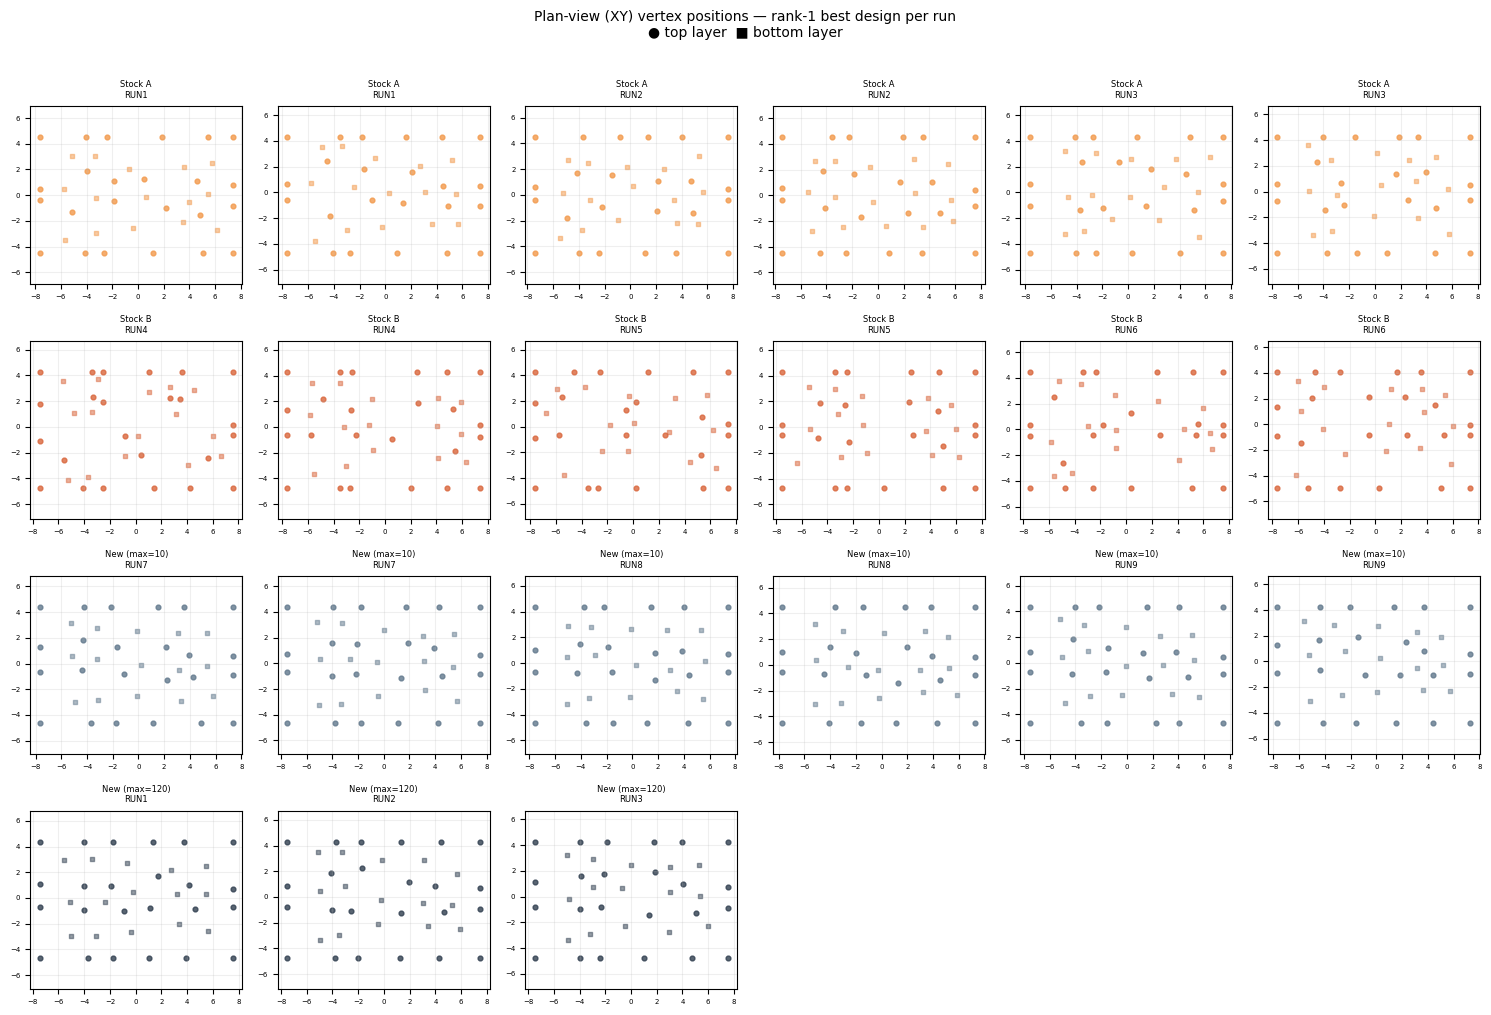

In [38]:
# ── 7c. Small-multiple plan views (top-view XY) ───────────────────────────
n_total = len(df)
ncols = 6
nrows = (n_total + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
axes_flat = axes.flatten() if nrows > 1 else axes

for ax_i, (_, row) in enumerate(df.iterrows()):
    ax = axes_flat[ax_i]
    verts = vertices.get(row['stem'])
    if verts is None or len(verts) == 0:
        ax.set_visible(False)
        continue
    top_v    = verts[verts['layer'] == 'top']
    bottom_v = verts[verts['layer'] == 'bottom']
    ax.scatter(top_v['x'],    top_v['y'],    s=12, color=COND_COLORS[row['condition']], marker='o', alpha=0.8, label='top')
    ax.scatter(bottom_v['x'], bottom_v['y'], s=12, color=COND_COLORS[row['condition']], marker='s', alpha=0.5, label='bottom')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_title(f"{row['condition']}\nRUN{row['run_num']}", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.grid(True, alpha=0.2)

# hide unused axes
for ax in axes_flat[n_total:]:
    ax.set_visible(False)

fig.suptitle('Plan-view (XY) vertex positions — rank-1 best design per run\n● top layer  ■ bottom layer', fontsize=10, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_plan_views.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table & Export

In [39]:
# ── Export raw run-level metrics ──────────────────────────────────────────
export_cols = [
    'stem', 'condition', 'run_num', 'seed', 'max_uses',
    'best_fitness', 'reuse_rate', 'total_cost', 'waste_total',
    'gnn_feasibility', 'n_unsafe_members', 'generation_found',
    'count_above_1', 'sum_util_above', 'max_util_above',
    'count_below_1', 'mean_util_safe', 'max_util_safe',
    'n_vertices', 'n_top', 'n_bottom',
    'z_range', 'z_mean_top', 'z_mean_bottom', 'xy_span_x', 'xy_span_y',
    'n_reclaimed_used', 'n_new_used',
]
df[export_cols].to_csv(OUTPUT_DIR / 'batch_run_metrics.csv', index=False)
df_agg_all.to_csv(OUTPUT_DIR / 'batch_aggregated_all.csv')
df_agg_best.to_csv(OUTPUT_DIR / 'batch_aggregated_best.csv')
print('Exported:', OUTPUT_DIR)

Exported: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\c30_output


In [40]:
# ── LaTeX-ready summary table (5 key metrics) ─────────────────────────────
TABLE_METRICS = [
    ('reuse_rate',      'Reuse rate',           '{:.1%}'),
    ('total_cost',      'Total cost',            '{:.1f}'),
    ('count_above_1',   'Over-utilised members', '{:.1f}'),
    ('gnn_feasibility', 'GNN feasibility',       '{:.3f}'),
    ('z_range',         'Height span (z) [m]',   '{:.3f}'),
]

rows_tex = []
for cond in COND_ORDER:
    grp = df[df['condition'] == cond]
    n   = len(grp)
    row = [cond, f'n={n}']
    for metric, _, fmt in TABLE_METRICS:
        vals = grp[metric].dropna()
        mean_str = fmt.format(vals.mean())
        std_str  = fmt.format(vals.std())
        row.append(f'{mean_str} ± {std_str}')
    rows_tex.append(row)

headers = ['Condition', 'N'] + [m[1] for m in TABLE_METRICS]
df_tex  = pd.DataFrame(rows_tex, columns=headers)

print('── Summary table ──')
display(df_tex.set_index('Condition'))

print('\n── LaTeX ──')
print(df_tex.set_index('Condition').to_latex(escape=True))

── Summary table ──


,N,Reuse rate,Total cost,Over-utilised members,GNN feasibility,Height span (z) [m]
Condition,,,,,,
Stock A,n=6,74.1% ± 1.1%,129.3 ± 1.4,8.0 ± 12.4,0.756 ± 0.006,2.579 ± 0.075
Stock B,n=6,80.6% ± 7.0%,143.1 ± 5.4,12.7 ± 19.6,0.758 ± 0.014,2.625 ± 0.001
New (max=10),n=6,0.0% ± 0.0%,195.7 ± 2.6,19.2 ± 16.6,0.738 ± 0.005,2.182 ± 0.158
New (max=120),n=3,0.0% ± 0.0%,198.2 ± 4.5,12.0 ± 20.8,0.746 ± 0.008,2.395 ± 0.299



── LaTeX ──
\begin{tabular}{lllllll}
\toprule
 & N & Reuse rate & Total cost & Over-utilised members & GNN feasibility & Height span (z) [m] \\
Condition &  &  &  &  &  &  \\
\midrule
Stock A & n=6 & 74.1\% ± 1.1\% & 129.3 ± 1.4 & 8.0 ± 12.4 & 0.756 ± 0.006 & 2.579 ± 0.075 \\
Stock B & n=6 & 80.6\% ± 7.0\% & 143.1 ± 5.4 & 12.7 ± 19.6 & 0.758 ± 0.014 & 2.625 ± 0.001 \\
New (max=10) & n=6 & 0.0\% ± 0.0\% & 195.7 ± 2.6 & 19.2 ± 16.6 & 0.738 ± 0.005 & 2.182 ± 0.158 \\
New (max=120) & n=3 & 0.0\% ± 0.0\% & 198.2 ± 4.5 & 12.0 ± 20.8 & 0.746 ± 0.008 & 2.395 ± 0.299 \\
\bottomrule
\end{tabular}



In [41]:
# ── Verification checks ───────────────────────────────────────────────────
print('=== Verification ===')
print(f'Total runs loaded:         {len(df)} (expected 21)')
print(f'df_best unique runs:       {len(df_best)}')

new_runs = df[df['condition'].isin(['New (max=10)', 'New (max=120)'])]
reuse_ok = (new_runs['reuse_rate'] == 0.0).all()
print(f'New stock reuse_rate = 0:  {reuse_ok} (expected True)')

# GA_B RUN4: two replicates — one may have 0, other may differ
b_run4 = df[(df['condition'] == 'Stock B') & (df['run_num'] == 4)]
if not b_run4.empty:
    print(f'GA_B RUN4 count_above_1:   {sorted(b_run4["count_above_1"].values)} (replicates may differ)')

# GA_new RUN7 (batch): count_above_1 should be ~36
new10_run7 = df[(df['condition'] == 'New (max=10)') & (df['run_num'] == 7)]
if not new10_run7.empty:
    print(f'GA_new RUN7 count_above_1: {new10_run7["count_above_1"].values} (expected ~[36, ...])')

# reuse_rate is LENGTH-weighted, n_reclaimed_used is COUNT-based — they will differ
# reuse_rate = Σ(length of RS_ members used) / Σ(length of all members)
# n_reclaimed_used / 120 = fraction by member count
df['reuse_count_frac'] = df['n_reclaimed_used'] / 120.0
delta = (df['reuse_rate'] - df['reuse_count_frac']).abs()
print(f'\nreuse_rate (length-weighted) vs n_reclaimed/120 (count-weighted):')
print(f'  Max delta: {delta.max():.4f}  — expected non-zero, both are valid metrics')
print()

# Summary of key results
print('=== Key results ===')
summary_table = df.groupby('condition', observed=True)[
    ['reuse_rate', 'total_cost', 'count_above_1', 'gnn_feasibility', 'z_range']
].agg(['mean', 'std']).round(3)
print(summary_table)

=== Verification ===
Total runs loaded:         21 (expected 21)
df_best unique runs:       12
New stock reuse_rate = 0:  True (expected True)
GA_B RUN4 count_above_1:   [np.int64(0), np.int64(38)] (replicates may differ)
GA_new RUN7 count_above_1: [34 36] (expected ~[36, ...])

reuse_rate (length-weighted) vs n_reclaimed/120 (count-weighted):
  Max delta: 0.1088  — expected non-zero, both are valid metrics

=== Key results ===
              reuse_rate        total_cost        count_above_1          \
                    mean    std       mean    std          mean     std   
condition                                                                 
Stock A            0.741  0.011    129.301  1.412         8.000  12.426   
Stock B            0.806  0.070    143.055  5.421        12.667  19.623   
New (max=10)       0.000  0.000    195.723  2.566        19.167  16.642   
New (max=120)      0.000  0.000    198.168  4.542        12.000  20.785   

              gnn_feasibility        z_ran

# Results Analysis

## 6.1 Pipeline performance

Three sub-systems are assessed to confirm the pipeline is technically valid before results are interpreted: the CMA-ES evolutionary strategy, the MILP material assignment solver, and the GNN structural proxy. Data comes directly from the 21 final-batch runs already loaded in sections 1–2 (no re-loading needed).

── CMA-ES per-condition summary (all 21 runs) ──
  Stock A           :  fitness -0.4796 ± 0.0052   gen_found 250 ± 0   σ_final 0.0239   penalty% 0.0%
  Stock B           :  fitness -0.2840 ± 0.0525   gen_found 250 ± 0   σ_final 0.0218   penalty% 0.0%
  New (max=10)      :  fitness 0.7031 ± 0.0042   gen_found 250 ± 0   σ_final 0.0143   penalty% 0.6%
  New (max=120)     :  fitness 0.7038 ± 0.0046   gen_found 250 ± 1   σ_final 0.0142   penalty% 0.0%


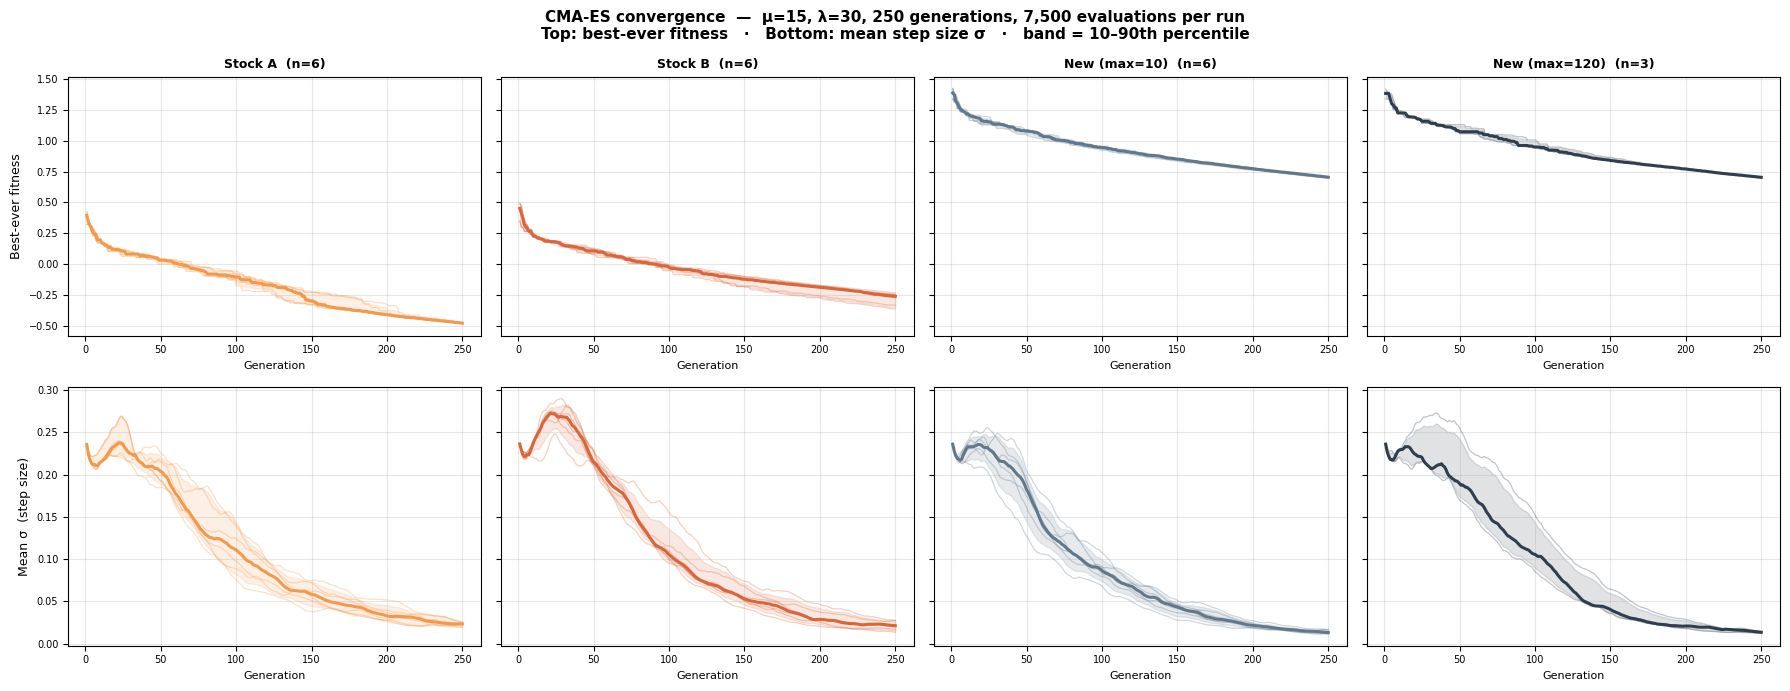

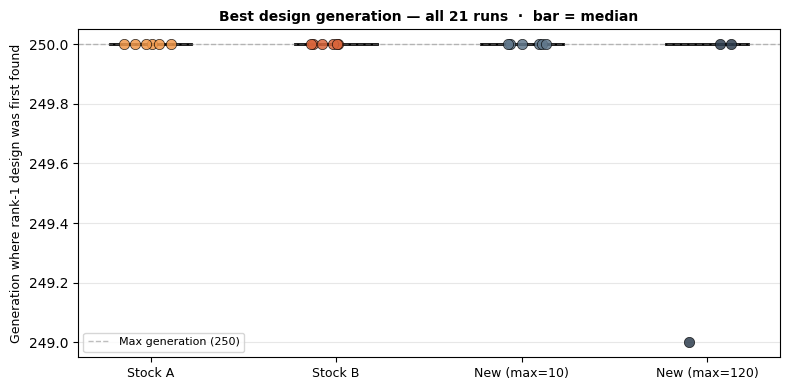

In [42]:
# =============================================================================
# 6.1.A  CMA-ES convergence — all 21 final-batch runs
# Uses: histories dict + df (sections 1-2). Adds sigma trajectory and penalty rate.
# =============================================================================

LAMBDA = 30  # offspring per generation (λ in CMA-ES config)

# ── Per-run convergence stats ─────────────────────────────────────────────────
stats_rows = []
for _, row in df.iterrows():
    hist         = histories[row['stem']]
    final_sigma  = hist['mean_sigma'].iloc[-10:].median()
    penalty_rate = (hist['n_penalty'] / LAMBDA).mean()
    stats_rows.append({
        'condition':        row['condition'],
        'best_fitness':     row['best_fitness'],
        'generation_found': row['generation_found'],
        'final_sigma':      final_sigma,
        'penalty_rate':     penalty_rate,
    })
df_stats = pd.DataFrame(stats_rows)
df_stats['condition'] = pd.Categorical(df_stats['condition'], categories=COND_ORDER, ordered=True)

print('── CMA-ES per-condition summary (all 21 runs) ──')
for cond in COND_ORDER:
    r = df_stats[df_stats['condition'] == cond]
    if r.empty:
        continue
    print(f'  {cond:<18}:  fitness {r["best_fitness"].mean():.4f} ± {r["best_fitness"].std():.4f}'
          f'   gen_found {r["generation_found"].mean():.0f} ± {r["generation_found"].std():.0f}'
          f'   σ_final {r["final_sigma"].mean():.4f}'
          f'   penalty% {r["penalty_rate"].mean():.1%}')

# ── Figure: top=best_ever, bottom=σ, four conditions ─────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
fig.suptitle(
    'CMA-ES convergence  —  μ=15, λ=30, 250 generations, 7,500 evaluations per run\n'
    'Top: best-ever fitness   ·   Bottom: mean step size σ   ·   band = 10–90th percentile',
    fontsize=11, fontweight='bold',
)

for ci, cond in enumerate(COND_ORDER):
    ax_t = axes[0][ci]
    ax_b = axes[1][ci]
    color = COND_COLORS[cond]
    runs  = df[df['condition'] == cond]
    mat_be, mat_sg = [], []
    gens = None

    for _, row in runs.iterrows():
        hist = histories[row['stem']]
        gens  = hist['generation'].values
        be    = hist['best_ever'].values
        sg    = hist['mean_sigma'].values
        mat_be.append(be);  mat_sg.append(sg)
        ax_t.plot(gens, be, alpha=0.30, lw=0.9, color=color)
        ax_b.plot(gens, sg, alpha=0.30, lw=0.9, color=color)

    if mat_be and gens is not None:
        for mat, ax in [(mat_be, ax_t), (mat_sg, ax_b)]:
            arr = np.array(mat)
            med = np.median(arr, axis=0)
            p10 = np.percentile(arr, 10, axis=0)
            p90 = np.percentile(arr, 90, axis=0)
            ax.plot(gens, med, lw=2.2, color=color)
            ax.fill_between(gens, p10, p90, alpha=0.15, color=color)

    n_r = len(runs)
    ax_t.set_title(f'{cond}  (n={n_r})', fontsize=9, fontweight='bold')
    for ax in [ax_t, ax_b]:
        ax.set_xlabel('Generation', fontsize=8)
        ax.grid(True, alpha=config.PLOT_STYLE['grid_alpha'])
        ax.tick_params(labelsize=7)

axes[0][0].set_ylabel('Best-ever fitness', fontsize=9)
axes[1][0].set_ylabel('Mean σ  (step size)', fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_61A_convergence_sigma.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Generation where rank-1 design was found ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for i, cond in enumerate(COND_ORDER):
    vals = df_stats[df_stats['condition'] == cond]['generation_found']
    ax.scatter(
        np.full(len(vals), i) + np.random.uniform(-0.15, 0.15, len(vals)),
        vals, color=COND_COLORS[cond], s=55, alpha=0.85, edgecolors='black', lw=0.5, zorder=3,
    )
    ax.plot([i - 0.22, i + 0.22], [vals.median(), vals.median()], color='black', lw=2.0)
ax.axhline(250, color='grey', lw=1.0, ls='--', alpha=0.5, label='Max generation (250)')
ax.set_xticks(range(len(COND_ORDER)))
ax.set_xticklabels(COND_ORDER, fontsize=9)
ax.set_ylabel('Generation where rank-1 design was first found', fontsize=9)
ax.set_title('Best design generation — all 21 runs  ·  bar = median', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=config.PLOT_STYLE['grid_alpha'])
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_61A_gen_found.png', dpi=150, bbox_inches='tight')
plt.show()


Model       : ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863
Architecture: TrussEdgeSafetyGNN  (4-layer GNN, hidden=64, BatchNorm, Residuals, Dropout=0.3)
Training    : 16k / 2k val / 2k test  ·  200 epochs  ·  best epoch = 186
Loss        : WeightedBCE (pos_weight=2.5)  ·  best val loss = 0.5893
ROC-AUC = 0.863  ·  PR-AUC = 0.615  ·  θ = 0.30 (recall-tuned)
Recall on unsafe: 86.6%  ·  False-negative rate: 11.4%


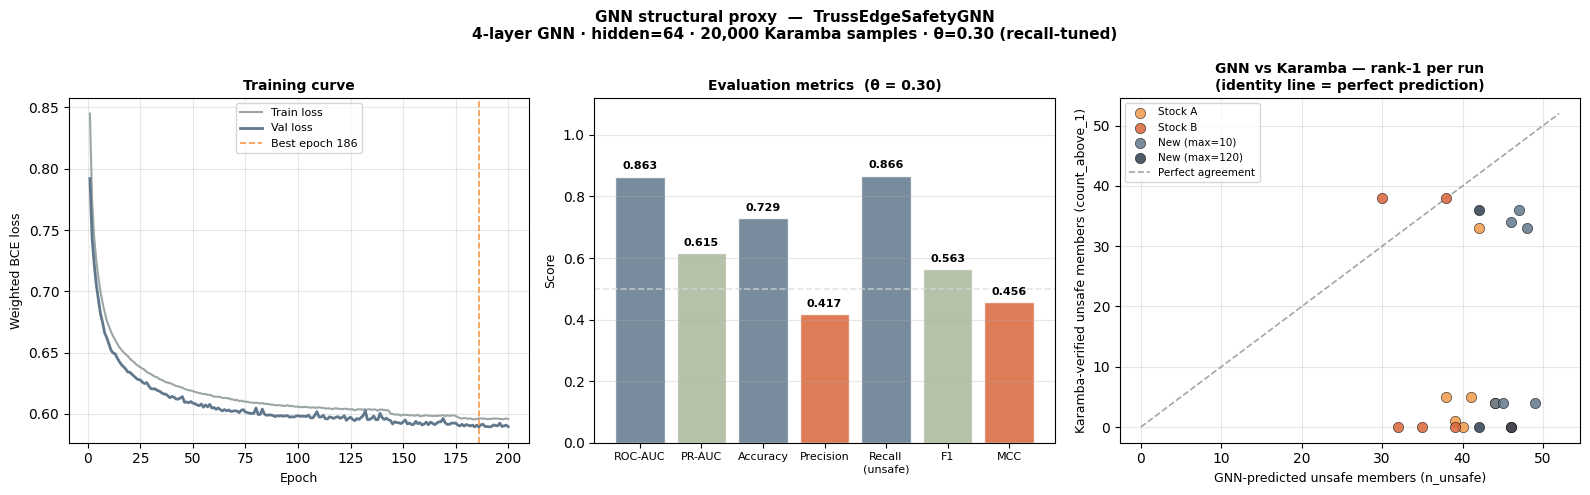


── GNN vs Karamba calibration (21 runs, rank-1 design) ──
  GNN predicted unsafe:  41.6 ± 5.0  members
  Karamba actual unsafe: 13.1 ± 15.9  members
  Mean residual:         +28.5 ± 16.5  (GNN − Karamba)
  Pearson correlation:   0.031
  → GNN overestimates by ~28.5 members on average.


In [43]:
# =============================================================================
# 6.1.B  GNN structural proxy — training report + calibration vs Karamba
# Training metrics come from the saved report file.
# Cross-validation uses n_unsafe_members (GNN) vs count_above_1 (Karamba) from df.
# =============================================================================

MODEL_PREFIX = 'ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863'
report_path  = config.SM_EXPORT_PATH / MODEL_PREFIX / f'{MODEL_PREFIX}_training_report.txt'

with open(report_path, encoding='utf-8') as f:
    report_text = f.read()

# Parse training history
hist_rows = []
for line in report_text.split('TRAINING HISTORY')[1].splitlines()[2:]:
    parts = line.strip().split(',')
    if len(parts) == 3:
        try:
            hist_rows.append([int(parts[0]), float(parts[1]), float(parts[2])])
        except ValueError:
            pass
df_hist    = pd.DataFrame(hist_rows, columns=['epoch', 'train_loss', 'val_loss'])
best_epoch = int(df_hist.loc[df_hist['val_loss'].idxmin(), 'epoch'])

# Known evaluation metrics (val-tuned θ=0.30)
eval_m = {
    'ROC-AUC':         0.863,
    'PR-AUC':          0.615,
    'Accuracy':        0.729,
    'Precision':       0.417,
    'Recall\n(unsafe)': 0.866,
    'F1':              0.563,
    'MCC':             0.456,
}

print(f'Model       : {MODEL_PREFIX}')
print(f'Architecture: TrussEdgeSafetyGNN  (4-layer GNN, hidden=64, BatchNorm, Residuals, Dropout=0.3)')
print(f'Training    : 16k / 2k val / 2k test  ·  200 epochs  ·  best epoch = {best_epoch}')
print(f'Loss        : WeightedBCE (pos_weight=2.5)  ·  best val loss = {df_hist["val_loss"].min():.4f}')
print(f'ROC-AUC = 0.863  ·  PR-AUC = 0.615  ·  θ = 0.30 (recall-tuned)')
print(f'Recall on unsafe: 86.6%  ·  False-negative rate: 11.4%')

# ── Figure: 3 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'GNN structural proxy  —  TrussEdgeSafetyGNN\n'
    '4-layer GNN · hidden=64 · 20,000 Karamba samples · θ=0.30 (recall-tuned)',
    fontsize=11, fontweight='bold',
)

# Panel 1: training curve
ax = axes[0]
ax.plot(df_hist['epoch'], df_hist['train_loss'], color=_PC['secondary'], lw=1.5, label='Train loss')
ax.plot(df_hist['epoch'], df_hist['val_loss'],   color=_PC['primary'],   lw=2.0, label='Val loss')
ax.axvline(best_epoch, color=_PC['accent'], lw=1.2, ls='--', label=f'Best epoch {best_epoch}')
ax.set_xlabel('Epoch', fontsize=9);  ax.set_ylabel('Weighted BCE loss', fontsize=9)
ax.set_title('Training curve', fontsize=10, fontweight='bold')
ax.legend(fontsize=8);  ax.grid(True, alpha=config.PLOT_STYLE['grid_alpha'])

# Panel 2: evaluation metrics bar
ax = axes[1]
names = list(eval_m.keys());  vals = list(eval_m.values())
bar_cols = [_PC['primary'] if v >= 0.70 else _EXT['soft_sage_green'] if v >= 0.50 else _PC['danger']
            for v in vals]
ax.bar(range(len(names)), vals, color=bar_cols, alpha=0.85, edgecolor='white')
ax.axhline(0.5, color=_PC['neutral'], lw=1.2, ls='--', alpha=0.7)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=8)
ax.set_ylim(0, 1.12);  ax.set_ylabel('Score', fontsize=9)
ax.set_title('Evaluation metrics  (θ = 0.30)', fontsize=10, fontweight='bold')
ax.grid(True, axis='y', alpha=config.PLOT_STYLE['grid_alpha'])
for i, v in enumerate(vals):
    ax.text(i, v + 0.025, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# Panel 3: GNN predicted vs Karamba verified (per run, rank-1)
ax = axes[2]
for cond in COND_ORDER:
    sub = df[df['condition'] == cond]
    ax.scatter(sub['n_unsafe_members'], sub['count_above_1'],
               label=cond, color=COND_COLORS[cond], s=55, alpha=0.85,
               edgecolors='black', linewidths=0.4, zorder=3)
max_v = max(df['n_unsafe_members'].max(), df['count_above_1'].max()) + 3
ax.plot([0, max_v], [0, max_v], color='grey', lw=1.2, ls='--', alpha=0.7, label='Perfect agreement')
ax.set_xlabel('GNN-predicted unsafe members (n_unsafe)', fontsize=9)
ax.set_ylabel('Karamba-verified unsafe members (count_above_1)', fontsize=9)
ax.set_title('GNN vs Karamba — rank-1 per run\n(identity line = perfect prediction)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5);  ax.grid(True, alpha=config.PLOT_STYLE['grid_alpha'])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_61B_gnn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Calibration stats ──────────────────────────────────────────────────────────
gnn_pred  = df['n_unsafe_members'].values.astype(float)
k_actual  = df['count_above_1'].values.astype(float)
residuals = gnn_pred - k_actual
corr      = pd.Series(gnn_pred).corr(pd.Series(k_actual))
print('\n── GNN vs Karamba calibration (21 runs, rank-1 design) ──')
print(f'  GNN predicted unsafe:  {gnn_pred.mean():.1f} ± {gnn_pred.std():.1f}  members')
print(f'  Karamba actual unsafe: {k_actual.mean():.1f} ± {k_actual.std():.1f}  members')
print(f'  Mean residual:         {residuals.mean():+.1f} ± {residuals.std():.1f}  (GNN − Karamba)')
print(f'  Pearson correlation:   {corr:.3f}')
print(f'  → GNN {"over" if residuals.mean() > 0 else "under"}estimates by ~{abs(residuals.mean()):.1f} members on average.')


In [44]:
# =============================================================================
# 6.1.C  MILP material assignment — summary
# Status confirmed from run report files. Solve time not exported by the GA runner.
# Stock pool composition loaded from run_config.json per condition.
# =============================================================================

print('── MILP status — all 21 rank-1 designs ──')
print('  Status: Optimal in all 21 runs  (confirmed from report files)')
print('  Solve time: not exported — only status (Optimal / Infeasible) is tracked.')
print()

# ── Stock pool sizes from run_config per condition ─────────────────────────────
_stem_to_dir = {d.name: d for d in EXTRA_NEW_120_DIRS}
for d in BATCH_DIR.iterdir():
    if d.is_dir():
        _stem_to_dir[d.name] = d

print('── Stock pool sizes per condition (from run_config.json) ──')
sample_stems = df.groupby('condition', observed=True)['stem'].first()
for cond, stem in sample_stems.items():
    cfg_path = _stem_to_dir[stem] / f'{stem}_run_config.json'
    with open(cfg_path) as f:
        rc = json.load(f)
    stock    = rc.get('stock', {})
    n_total  = stock.get('n_total', '?')
    n_ns     = stock.get('n_ns', '?')
    n_rs     = stock.get('n_rs', '?')
    max_uses = rc.get('new_stock_max_uses',
                      rc.get('ga_config', {}).get('new_stock_max_uses', '?'))
    print(f'  {cond:<18}: total pool = {n_total}  '
          f'(NS={n_ns}, RS={n_rs})  max_uses={max_uses}')

# ── Members assigned per run (from df) ────────────────────────────────────────
print()
print('── Mean members assigned per run (rank-1, 120 slots) ──')
for cond in COND_ORDER:
    sub = df[df['condition'] == cond]
    rs_m = sub['n_reclaimed_used'].mean();  rs_s = sub['n_reclaimed_used'].std()
    ns_m = sub['n_new_used'].mean();        ns_s = sub['n_new_used'].std()
    total_m = rs_m + ns_m
    print(f'  {cond:<18}: RS = {rs_m:.0f} ± {rs_s:.1f}   '
          f'NS = {ns_m:.0f} ± {ns_s:.1f}   total = {total_m:.0f}')

print()
print('  Note: total assigned < 120 if some edges were unmatched (geometry filter).')
print('  All rank-1 designs confirmed Optimal — feasible pairings exist for every geometry.')


── MILP status — all 21 rank-1 designs ──
  Status: Optimal in all 21 runs  (confirmed from report files)
  Solve time: not exported — only status (Optimal / Infeasible) is tracked.

── Stock pool sizes per condition (from run_config.json) ──
  Stock A           : total pool = 524  (NS=421, RS=103)  max_uses=10
  Stock B           : total pool = 576  (NS=421, RS=155)  max_uses=10
  New (max=10)      : total pool = 421  (NS=421, RS=0)  max_uses=10
  New (max=120)     : total pool = 421  (NS=421, RS=0)  max_uses=120

── Mean members assigned per run (rank-1, 120 slots) ──
  Stock A           : RS = 86 ± 0.5   NS = 34 ± 0.5   total = 120
  Stock B           : RS = 91 ± 3.0   NS = 29 ± 3.0   total = 120
  New (max=10)      : RS = 0 ± 0.0   NS = 120 ± 0.0   total = 120
  New (max=120)     : RS = 0 ± 0.0   NS = 120 ± 0.0   total = 120

  Note: total assigned < 120 if some edges were unmatched (geometry filter).
  All rank-1 designs confirmed Optimal — feasible pairings exist for every geomet

## 6.2 Comparative analysis

Four comparisons using raw physical metrics from the 21 final-batch runs (df, df_best, df_agg_all from sections 1–3). Fitness is NOT used for cross-condition comparison (different normalisation constants per stock).

### 6.2.1 Static baseline vs GA-optimised design

Compares the **unoptimised static regular-grid** space frame (default 5×3 grid, 3 m edge, 1.5 m depth) against the best GA-optimised design from the final batch (Stock A, RUN1, seed 42). Both are evaluated through the **identical pipeline** — feasibility filter → MILP material assignment → GNN structural proxy → fitness — using the same stock inventory, normalisation constants, fitness weights, and GNN model. The metric delta isolates the gain from geometry adaptation alone.

**Note:** fitness comparison is valid here because both designs use the same Stock A normalisation bounds (unlike cross-condition comparisons in §6.2.3).

Static space frame  |  39 nodes  |  120 members  (38 top / 22 bot / 60 web)


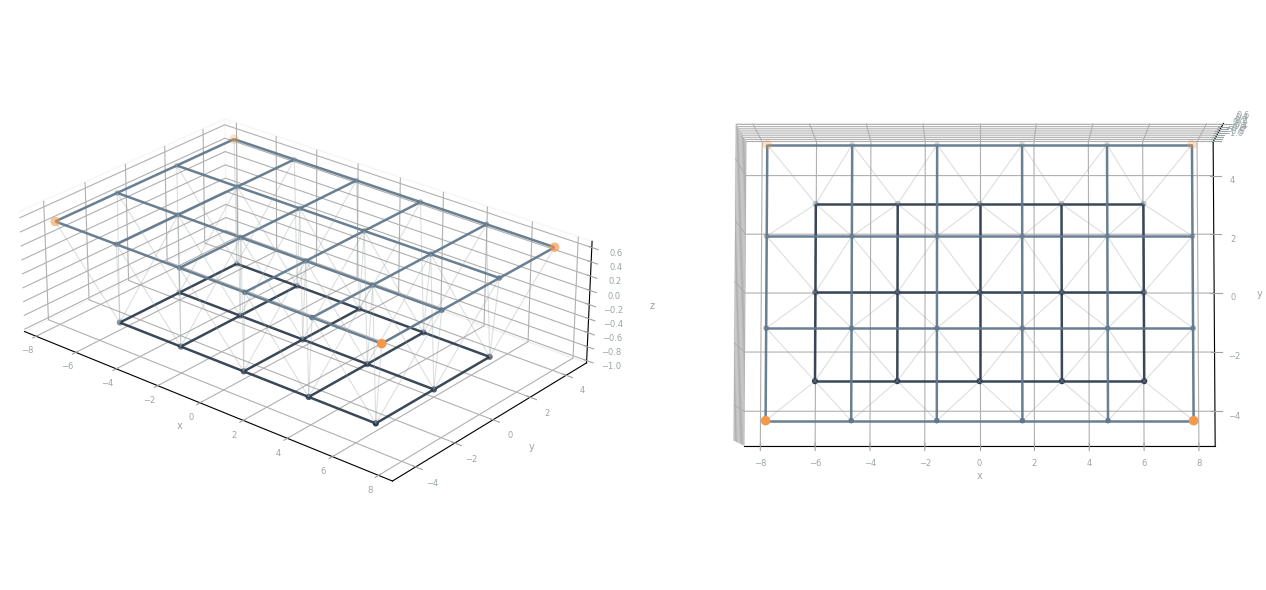

In [46]:
# =============================================================================
# Build static regular-grid space frame
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from collections import Counter
import importlib
import config
import c00_headquarter_params as c00
import c22_stage_geometry as stage_geometry

importlib.reload(stage_geometry)

static_geo = stage_geometry.run_geometry_from_design({}, sample_id=0)
df_v_s  = static_geo["df_vertices"]
df_e_s  = static_geo["df_edges"]
df_geo_s = static_geo["df_geometry_overview"]

_vlu_s = (
    df_v_s
    .set_index("vertex_index")[["x", "y", "z", "layer", "attribute"]]
    .to_dict("index")
)

def _vk(v):
    s = str(v)
    return s if s.startswith("v") else f"v{s}"

_mtypes = []
for _, e in df_e_s.iterrows():
    l1 = _vlu_s[_vk(e["V1"])]["layer"]
    l2 = _vlu_s[_vk(e["V2"])]["layer"]
    _mtypes.append(
        "top_chord" if (l1 == l2 == "top")
        else "bot_chord" if (l1 == l2 == "bottom")
        else "web"
    )
df_geo_s["member_type"] = _mtypes
_ct = Counter(_mtypes)

n_top = int((df_v_s["layer"] == "top").sum())
n_bot = int((df_v_s["layer"] == "bottom").sum())
print(f"Static space frame  |  {len(df_v_s)} nodes  |  {len(df_e_s)} members  "
      f"({_ct['top_chord']} top / {_ct['bot_chord']} bot / {_ct['web']} web)")

# Palette — from config
C_NS    = "#61788C"
C_DARK  = "#2F3E4F"
C_MUTED = "#9CA5A6"
C_RS    = "#F2994B"

_MSTYLE = dict(
    top_chord=dict(color=C_NS,    lw=1.8, alpha=0.95),
    bot_chord=dict(color=C_DARK,  lw=1.8, alpha=0.95),
    web      =dict(color=C_MUTED, lw=0.8, alpha=0.35),
)

_v1k = df_e_s["V1"].map(lambda v: v if str(v).startswith("v") else f"v{v}")
_v2k = df_e_s["V2"].map(lambda v: v if str(v).startswith("v") else f"v{v}")
_all_segs = np.array([
    [[_vlu_s[v1]["x"], _vlu_s[v1]["y"], _vlu_s[v1]["z"]],
     [_vlu_s[v2]["x"], _vlu_s[v2]["y"], _vlu_s[v2]["z"]]]
    for v1, v2 in zip(_v1k, _v2k)
])
_mt_arr = np.array(_mtypes)

_sup_m = df_v_s["attribute"] == "support"
_bot_m = (~_sup_m) & (df_v_s["layer"] == "bottom")
_top_m = (~_sup_m) & (df_v_s["layer"] == "top")
_xs = df_v_s["x"].values
_ys = df_v_s["y"].values
_zs = df_v_s["z"].values

fig_static, (ax_p, ax_t) = plt.subplots(
    1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"},
)
fig_static.patch.set_facecolor("white")

def _style_ax_3d(ax):
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#EEEEEE")
    ax.yaxis.pane.set_edgecolor("#EEEEEE")
    ax.zaxis.pane.set_edgecolor("#EEEEEE")
    ax.grid(True, color="#EEEEEE", linewidth=0.4, alpha=0.5)
    ax.set_xlabel("x", fontsize=7, color=C_MUTED, labelpad=0)
    ax.set_ylabel("y", fontsize=7, color=C_MUTED, labelpad=0)
    ax.set_zlabel("z", fontsize=7, color=C_MUTED, labelpad=2)
    ax.tick_params(labelsize=6, colors=C_MUTED, pad=1)

for ax, elev, azim in [(ax_p, 26, -50), (ax_t, 85, -90)]:
    for mt, style in _MSTYLE.items():
        ax.add_collection3d(Line3DCollection(_all_segs[_mt_arr == mt], **style))
    for mask, col, ms in [(_sup_m, C_RS, 48), (_bot_m, C_DARK, 20), (_top_m, C_NS, 16)]:
        sub = df_v_s[mask]
        ax.scatter3D(sub["x"].values, sub["y"].values, sub["z"].values,
                     c=col, s=ms, zorder=5, edgecolors="none")
    ax.auto_scale_xyz(_xs, _ys, _zs)
    ax.set_box_aspect((1, 0.65, 0.28))
    ax.view_init(elev=elev, azim=azim)
    _style_ax_3d(ax)
    if elev > 80:
        ax.set_zlabel("")

plt.tight_layout()
fig_static.savefig(OUTPUT_DIR / "fig_static_geometry.png", dpi=150, bbox_inches="tight")
plt.show()


In [47]:
# Export static grid to 01_geometry_data for Grasshopper inspection
df_vertices_static = df_v_s.copy()
df_edges_static    = df_e_s.copy()
df_edges_static.insert(0, "sample_id", 0)

_out = config.GEOM_DATA_PATH
_out.mkdir(parents=True, exist_ok=True)

_vpath = _out / "static_grid_vertices.csv"
_epath = _out / "static_grid_edges.csv"

df_vertices_static.to_csv(_vpath, index=False)
df_edges_static.to_csv(_epath, index=False)

print(f"Saved: {_vpath}")
print(f"Saved: {_epath}")
print(f"  Vertices: {len(df_vertices_static)} rows  {list(df_vertices_static.columns)}")
print(f"  Edges:    {len(df_edges_static)} rows  {list(df_edges_static.columns)}")

Saved: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_geometry_data\static_grid_vertices.csv
Saved: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_geometry_data\static_grid_edges.csv
  Vertices: 39 rows  ['sample_id', 'vertex_index', 'layer', 'attribute', 'x', 'y', 'z']
  Edges:    120 rows  ['sample_id', 'edge_id', 'V1', 'V2']


GA run  : GA_A_20260520_214422_RUN1_GEN250_EVAL7500_F-0_4852
Stock   : C:\Users\VR Guest\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\03_timber_data\complete_timber_A.csv  (524 elements,  NS=421  RS=103)
Norm    : C_max=397.4531   R_max=0.7273
GA best : reuse=75.0%  cost=128.66  gnn=0.7611  count_above=0

Stock A loaded: 524 elements

──────────────────────────────────────────────────────────────
Running static grid  (design_params={})  …
──────────────────────────────────────────────────────────────
    ✓ geometry    | 39 nodes, 120 edges
  Stage 1 (length):    38,460 eliminated  (24,420 remaining, 38.8%)
  Stage 2 (force):   max tension=12.0 kN  max compression=-10.4 kN  mean |F|=4.5 kN
  Stage 3 (EC5):        3,980 eliminated  (20,440 remaining, 32.5%)
    ✓ feasibility | 20,440 feasible slot/stock pairs
    ✓ cost matrix | 20,440 finite entries
    ✓ MILP        | status=Optimal, cost=117.1860, 120 assignments
[IO] Inference config loaded from ID20260516_182257_LR

,Static grid,GA optimised,delta (GA-static)
Metric,,,
Total cost (kg CO2e),117.1860,128.6580,+11.4720
Reuse fraction,0.3026,0.7496,+0.4470
GNN feasibility,0.6592,0.7611,+0.1019
Over-util members (GH),nan,0.0000,+nan
Best-ever fitness,0.1515,-0.4852,-0.6367
MILP status,Optimal,Optimal,n/a


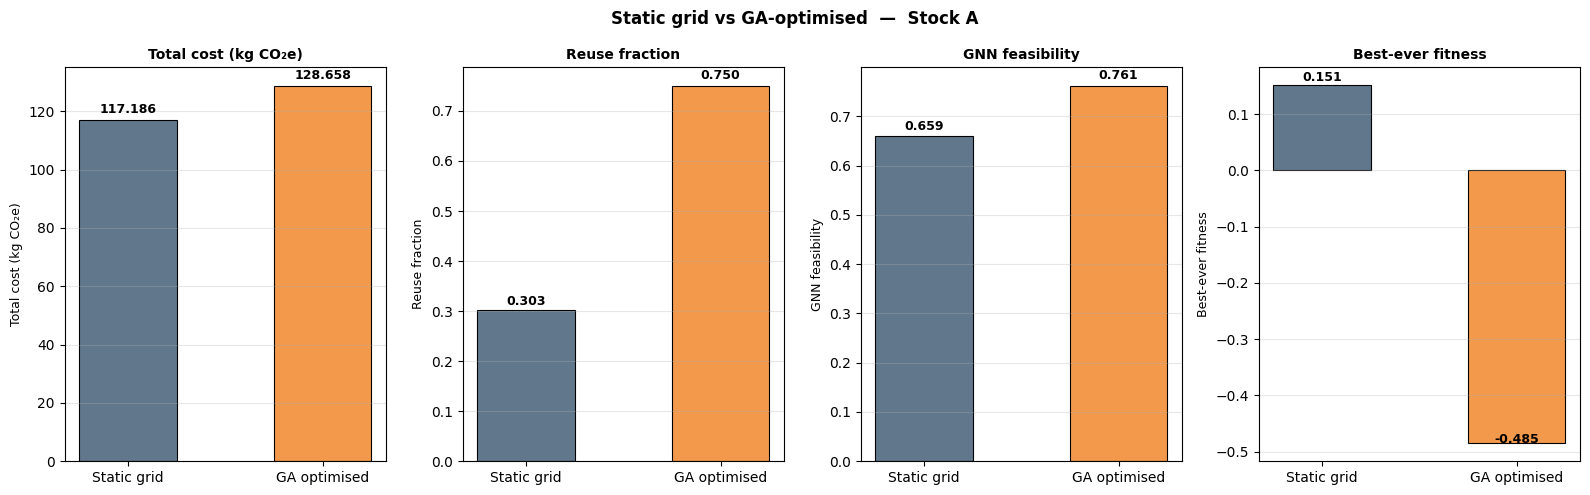

In [48]:
# =============================================================================
# 6.2.1  Static regular-grid vs GA-optimised design
# Static grid is run through the full pipeline; GA metrics come from df_best
# (computed in section 2) — no separate file loading needed.
# Normalization constants are loaded from the best Stock A run_config.
# =============================================================================
import importlib
from workflows import c22_stage_geometry as stage_geometry
from workflows import c27_stage_GNN      as stage_gnn
from workflows import c23_ga_evaluator   as ga_eval

for _m in [stage_geometry, stage_gnn, ga_eval]:
    importlib.reload(_m)

# ── Pull best Stock A run from df_best ────────────────────────────────────────
_ga_row  = df_best[df_best['condition'] == 'Stock A'].sort_values('best_fitness').iloc[0]
_GA_STEM = _ga_row['stem']
_GA_DIR  = BATCH_DIR / _GA_STEM

with open(_GA_DIR / f'{_GA_STEM}_run_config.json', encoding='utf-8') as f:
    _rc = json.load(f)

_NORM    = _rc['normalization_constants']
_MPREFIX = _rc['model_prefix']
_GC      = _rc['ga_config']

_GA_CONFIG_STATIC = {
    'fitness_weights':    _GC['fitness_weights'],
    'new_stock_max_uses': _GC['new_stock_max_uses'],
    'min_reuse_fraction': _GC['min_reuse_fraction'],
    'penalty_fitness':    _GC['penalty_fitness'],
    'w_structural_start': _GC['w_structural_start'],
    'w_structural_end':   _GC['w_structural_end'],
    'use_gnn':            _GC['use_gnn'],
}

print(f'GA run  : {_GA_STEM}')
print(f'Stock   : {_rc["stock"]["source"]}  '
      f'({_rc["stock"]["n_total"]} elements,  NS={_rc["stock"]["n_ns"]}  RS={_rc["stock"]["n_rs"]})')
print(f'Norm    : C_max={_NORM["C_max"]:.4f}   R_max={_NORM["R_max"]:.4f}')
print(f'GA best : reuse={float(_ga_row["reuse_rate"]):.1%}  '
      f'cost={float(_ga_row["total_cost"]):.2f}  '
      f'gnn={float(_ga_row["gnn_feasibility"]):.4f}  '
      f'count_above={int(_ga_row["count_above_1"])}')

# ── Load Stock A ──────────────────────────────────────────────────────────────
_stock_path = config.TIMBER_STOCK_PATH / 'complete_timber_A.csv'
df_stock_A = None
for _opts in [{'sep': ';', 'encoding': 'utf-8'}, {'sep': ',', 'encoding': 'utf-8'},
              {'sep': ';', 'encoding': 'latin1'}, {'sep': ',', 'encoding': 'latin1'}]:
    try:
        _df = pd.read_csv(_stock_path, **_opts)
        if _df.shape[1] > 1:
            df_stock_A = _df
            break
    except Exception:
        pass
df_stock_A.columns = df_stock_A.columns.str.strip()
_prep_gnn_A = stage_gnn.prepare_stock_for_gnn(df_stock_A)
print(f'\nStock A loaded: {len(df_stock_A)} elements\n')

# ── Run static grid through the full pipeline ─────────────────────────────────
print('\u2500' * 62)
print('Running static grid  (design_params={})  \u2026')
print('\u2500' * 62)
_static_eval = ga_eval.evaluate_design_candidate(
    design_params        = {},
    df_stock             = df_stock_A,
    fixed_norm_constants = _NORM,
    config_dict          = _GA_CONFIG_STATIC,
    model_prefix         = _MPREFIX,
    generation           = 250,
    max_generations      = 250,
    sample_id            = 0,
    verbose              = True,
    prepared_gnn_stock   = _prep_gnn_A,
)
print(f'\nStatic eval status: {_static_eval["status"]}')

# ── Comparison table: static vs GA best (from df_best) ────────────────────────
_sfr = _static_eval.get('fitness_result', {})
_row_defs = [
    ('Total cost (kg CO2e)',   _static_eval.get('total_cost',      float('nan')), float(_ga_row['total_cost'])),
    ('Reuse fraction',         _static_eval.get('reuse_fraction',  float('nan')), float(_ga_row['reuse_rate'])),
    ('GNN feasibility',        _static_eval.get('gnn_feasibility', float('nan')), float(_ga_row['gnn_feasibility'])),
    ('Over-util members (GH)', float('nan'),                                       float(_ga_row['count_above_1'])),
    ('Best-ever fitness',      _sfr.get('fitness', float('nan')),                  float(_ga_row['best_fitness'])),
    ('MILP status',            _static_eval.get('milp_status', 'unknown'),        'Optimal'),
]
_rows = []
for label, sv, gv in _row_defs:
    delta = f'{gv - sv:+.4f}' if isinstance(sv, float) and isinstance(gv, float) else 'n/a'
    _rows.append({
        'Metric':           label,
        'Static grid':      f'{sv:.4f}' if isinstance(sv, float) else sv,
        'GA optimised':     f'{gv:.4f}' if isinstance(gv, float) else gv,
        'delta (GA-static)': delta,
    })
df_comparison = pd.DataFrame(_rows).set_index('Metric')
print(f'\n{"=" * 62}')
print(f'STATIC GRID  vs  GA-OPTIMISED  ({_GA_STEM[:30]}...)')
print(f'{"=" * 62}')
display(df_comparison)

# ── Bar chart: 4 comparable raw metrics incl. fitness ───────────────────────
_fitness_static = _sfr.get("fitness", float("nan"))
_fitness_ga     = float(_ga_row["best_fitness"])
_bar_data = [
    ('Total cost (kg CO₂e)',  _static_eval.get('total_cost',      float('nan')), float(_ga_row['total_cost'])),
    ('Reuse fraction',           _static_eval.get('reuse_fraction',  float('nan')), float(_ga_row['reuse_rate'])),
    ('GNN feasibility',          _static_eval.get('gnn_feasibility', float('nan')), float(_ga_row['gnn_feasibility'])),
    ('Best-ever fitness',        _fitness_static,                                    _fitness_ga),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Static grid vs GA-optimised  —  Stock A',
             fontsize=12, fontweight='bold')
for ax, (title, sv, gv) in zip(axes, _bar_data):
    bars = ax.bar(['Static grid', 'GA optimised'], [sv, gv],
                  color=[_PC['NS'], COND_COLORS['Stock A']],
                  edgecolor='black', linewidth=0.8, width=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(title, fontsize=9)
    ax.grid(True, axis='y', alpha=config.PLOT_STYLE['grid_alpha'])
    for bar, val in zip(bars, [sv, gv]):
        if not (isinstance(val, float) and np.isnan(val)):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_static_vs_optimized.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2.2 Stock A vs Stock B

Both conditions use mixed stock (RS_ reclaimed + NS_ supplement), same GA configuration, different reclaimed lot. Compares reuse rate, cost, structural violations, and geometry across 6 runs each.

── Stock A vs B: aggregated metrics (all runs) ──


reuse_rate        total_cost        count_above_1          \
                mean    std       mean    std          mean     std   
condition                                                             
Stock A        0.741  0.011    129.301  1.412         8.000  12.426   
Stock B        0.806  0.070    143.055  5.421        12.667  19.623   

          gnn_feasibility        z_range        n_reclaimed_used         
                     mean    std    mean    std             mean    std  
condition                                                                
Stock A             0.756  0.006   2.579  0.075           85.667  0.516  
Stock B             0.758  0.014   2.625  0.001           91.167  2.994

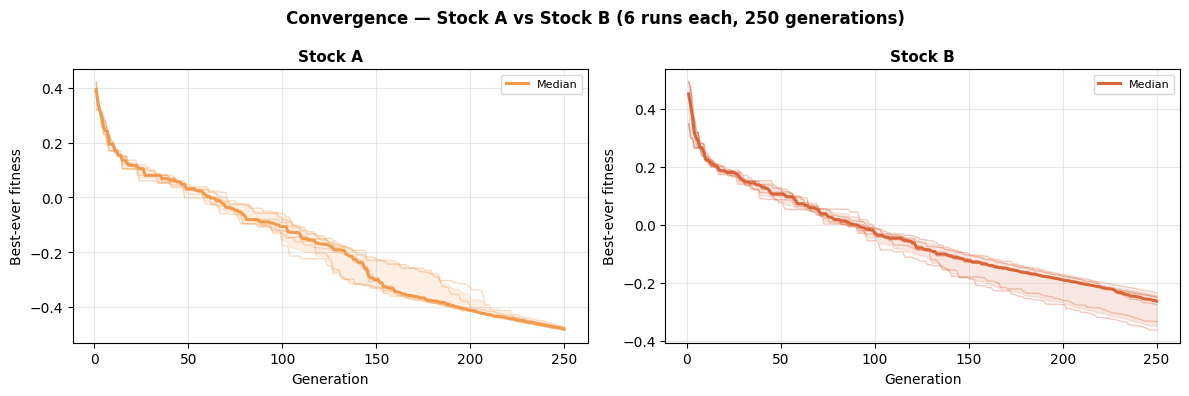

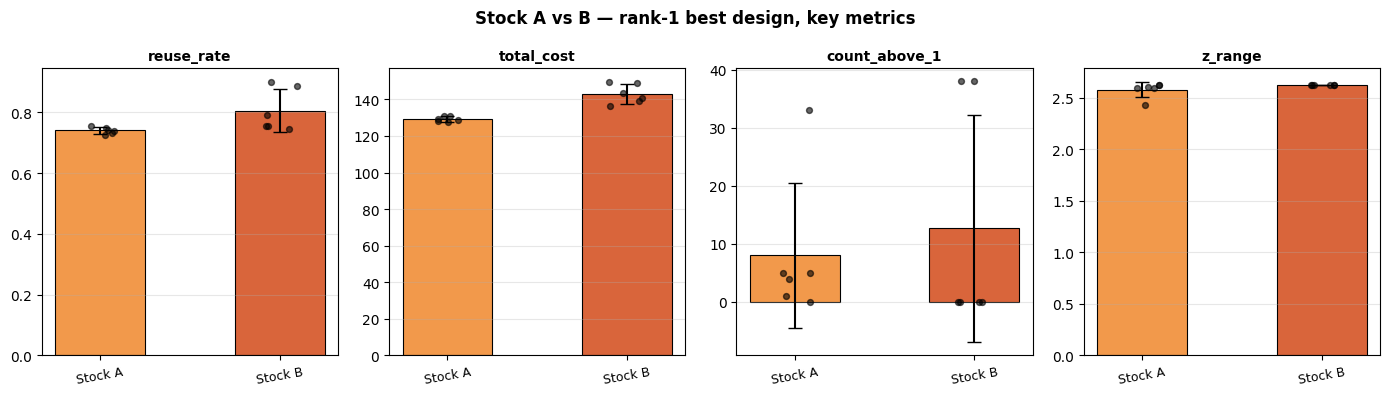

In [49]:
# 6.3.2  Stock A vs Stock B
# Both use mixed stock (RS_ + NS_), same GA config, different reclaimed lot.
# All metrics read directly from df, df_best, histories (sections 1-2).
COND_AB = ['Stock A', 'Stock B']
df_ab   = df[df['condition'].isin(COND_AB)]

# A. Aggregated metrics table
show_metrics = ['reuse_rate', 'total_cost', 'count_above_1', 'gnn_feasibility', 'z_range', 'n_reclaimed_used']
ab_agg = df_ab.groupby('condition', observed=True)[show_metrics].agg(['mean', 'std']).round(3)
print('\u2500\u2500 Stock A vs B: aggregated metrics (all runs) \u2500\u2500')
display(ab_agg)

# B. Convergence (A and B only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cond in zip(axes, COND_AB):
    color = COND_COLORS[cond]
    all_be = []
    for _, row in df[df['condition'] == cond].iterrows():
        hist = histories[row['stem']]
        gens = hist['generation'].values
        be   = hist['best_ever'].values
        all_be.append(be)
        ax.plot(gens, be, alpha=0.35, lw=1.0, color=color)
    if all_be:
        mat = np.array(all_be)
        ax.plot(gens, np.median(mat, axis=0), lw=2.2, color=color, label='Median')
        ax.fill_between(gens, np.percentile(mat, 10, axis=0), np.percentile(mat, 90, axis=0),
                        alpha=0.15, color=color)
    ax.set_title(cond, fontsize=11, fontweight='bold')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Best-ever fitness')
    ax.grid(True, alpha=config.PLOT_STYLE['grid_alpha'])
    ax.legend(fontsize=8)
fig.suptitle('Convergence \u2014 Stock A vs Stock B (6 runs each, 250 generations)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_AB_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# C. Bar chart: key physical metrics
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Stock A vs B \u2014 rank-1 best design, key metrics', fontsize=12, fontweight='bold')
for ax, metric in zip(axes, ['reuse_rate', 'total_cost', 'count_above_1', 'z_range']):
    means = [df_ab[df_ab['condition'] == c][metric].mean() for c in COND_AB]
    stds  = [df_ab[df_ab['condition'] == c][metric].std()  for c in COND_AB]
    ax.bar(COND_AB, means, yerr=stds, capsize=5,
           color=[COND_COLORS[c] for c in COND_AB], edgecolor='black', linewidth=0.8, width=0.5)
    for i, cond in enumerate(COND_AB):
        vals = df_ab[df_ab['condition'] == cond][metric].dropna()
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.1, 0.1, len(vals)),
                   vals, color='black', s=18, zorder=5, alpha=0.6)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=config.PLOT_STYLE['grid_alpha'])
    ax.tick_params(axis='x', rotation=10, labelsize=9)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_AB_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2.3 Stock A & B vs New Timber

Full three-condition comparison. Fitness normalisation differs between conditions — cross-condition comparison uses raw physical metrics only (reuse_rate, total_cost, count_above_1, z_range).

── Cross-condition summary: A, B, New-10 ──


,reuse_rate_mean,reuse_rate_std,total_cost_mean,total_cost_std,count_above_1_mean,count_above_1_std,gnn_feasibility_mean,gnn_feasibility_std
condition,,,,,,,,
Stock A,0.741,0.011,129.301,1.412,8.000,12.426,0.756,0.006
Stock B,0.806,0.070,143.055,5.421,12.667,19.623,0.758,0.014
New (max=10),0.000,0.000,195.723,2.566,19.167,16.642,0.738,0.005


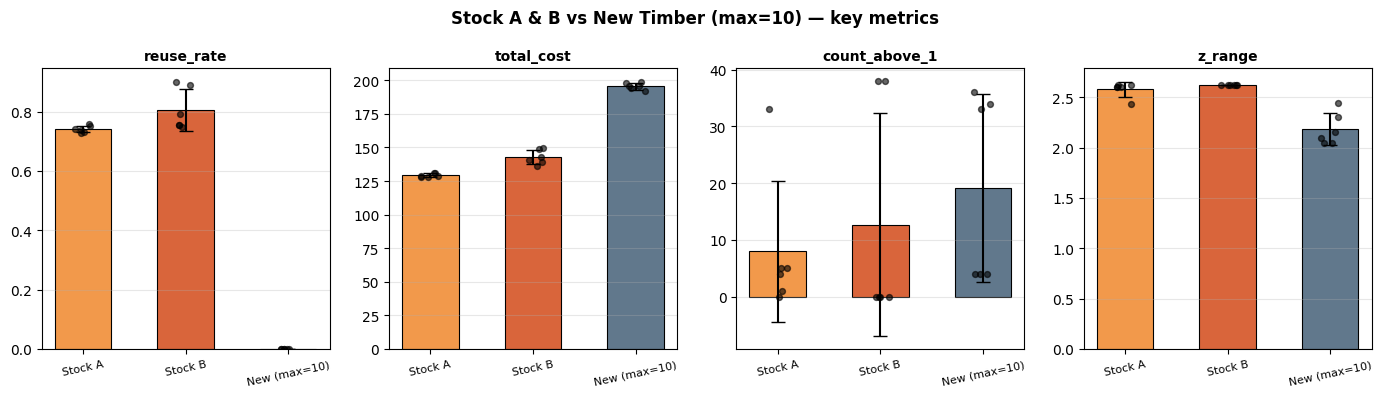


── Key findings ──
  Stock A           : reuse=74.1%  cost=129.3  count_above=8.0  z_range=2.58 m
  Stock B           : reuse=80.6%  cost=143.1  count_above=12.7  z_range=2.62 m
  New (max=10)      : reuse=0.0%  cost=195.7  count_above=19.2  z_range=2.18 m

  Cost vs New-10:
    Stock A: 33.9% lower  (delta=-66.4)
    Stock B: 26.9% lower  (delta=-52.7)


In [50]:
# 6.3.3  Stock A & B vs New Timber
# Sections 4-7 above show full cross-condition analysis.
# This cell adds a focused 3-condition summary and cost-reduction delta.
COND_3 = ['Stock A', 'Stock B', 'New (max=10)']
df_3   = df[df['condition'].isin(COND_3)]

print('── Cross-condition summary: A, B, New-10 ──')
show_c = ['reuse_rate_mean', 'reuse_rate_std',
          'total_cost_mean', 'total_cost_std',
          'count_above_1_mean', 'count_above_1_std',
          'gnn_feasibility_mean', 'gnn_feasibility_std']
display(df_agg_all.loc[COND_3, show_c].round(3))

# Focused bar chart: 3 conditions
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Stock A & B vs New Timber (max=10) — key metrics', fontsize=12, fontweight='bold')
for ax, metric in zip(axes, ['reuse_rate', 'total_cost', 'count_above_1', 'z_range']):
    means = [df_3[df_3['condition'] == c][metric].mean() for c in COND_3]
    stds  = [df_3[df_3['condition'] == c][metric].std()  for c in COND_3]
    ax.bar(COND_3, means, yerr=stds, capsize=5,
           color=[COND_COLORS[c] for c in COND_3], edgecolor='black', linewidth=0.8, width=0.55)
    for i, cond in enumerate(COND_3):
        vals = df_3[df_3['condition'] == cond][metric].dropna()
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.1, 0.1, len(vals)),
                   vals, color='black', s=18, zorder=5, alpha=0.6)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=config.PLOT_STYLE['grid_alpha'])
    ax.tick_params(axis='x', rotation=12, labelsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_ABvNew_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings
print('\n── Key findings ──')
new10   = df_agg_all.loc['New (max=10)']
stock_a = df_agg_all.loc['Stock A']
stock_b = df_agg_all.loc['Stock B']
for cond in COND_3:
    r = df_agg_all.loc[cond]
    print(f'  {cond:<18}: reuse={r["reuse_rate_mean"]:.1%}  '
          f'cost={r["total_cost_mean"]:.1f}  '
          f'count_above={r["count_above_1_mean"]:.1f}  '
          f'z_range={r["z_range_mean"]:.2f} m')
_pct_a = (1 - stock_a['total_cost_mean'] / new10['total_cost_mean']) * 100
_pct_b = (1 - stock_b['total_cost_mean'] / new10['total_cost_mean']) * 100
_dir_a = 'lower' if stock_a['total_cost_mean'] < new10['total_cost_mean'] else 'higher'
_dir_b = 'lower' if stock_b['total_cost_mean'] < new10['total_cost_mean'] else 'higher'
print(f'\n  Cost vs New-10:')
print(f'    Stock A: {abs(_pct_a):.1f}% {_dir_a}  (delta={stock_a["total_cost_mean"] - new10["total_cost_mean"]:+.1f})')
print(f'    Stock B: {abs(_pct_b):.1f}% {_dir_b}  (delta={stock_b["total_cost_mean"] - new10["total_cost_mean"]:+.1f})')

### 6.2.4 New max=10 vs New max=120 — seed-matched

Key question: does relaxing member reuse from 10→120 improve results? Seed-matched comparison (seeds 42/43/44, n=3 each).

── Seed-matched: New max=10 vs New max=120 (n=3 each, seeds 42/43/44) ──
(reuse_rate = 0.0 for both — fresh timber, no RS members)



count_above_1               gnn_feasibility                \
condition  New (max=10) New (max=120)    New (max=10) New (max=120)   
seed                                                                  
42                 34.0           0.0           0.733         0.736   
43                 33.0          36.0           0.733         0.749   
44                  4.0           0.0           0.735         0.751   

            total_cost                    z_range                
condition New (max=10) New (max=120) New (max=10) New (max=120)  
seed                                                             
42             191.830       192.977        2.043         2.057  
43             194.373       201.406        2.050         2.625  
44             195.421       200.122        2.158         2.502


── Aggregated (seed-matched) ──


total_cost         waste_total         count_above_1           \
                    mean     std        mean     std          mean      std   
condition                                                                     
New (max=10)    193.8745  1.8467      7.4754  0.6160       23.6667  17.0392   
New (max=120)   198.1683  4.5417      9.2485  0.3814       12.0000  20.7846   

              gnn_feasibility         z_range         best_fitness          
                         mean     std    mean     std         mean     std  
condition                                                                   
New (max=10)           0.7341  0.0012  2.0837  0.0645       0.7019  0.0040  
New (max=120)          0.7455  0.0084  2.3947  0.2988       0.7038  0.0046

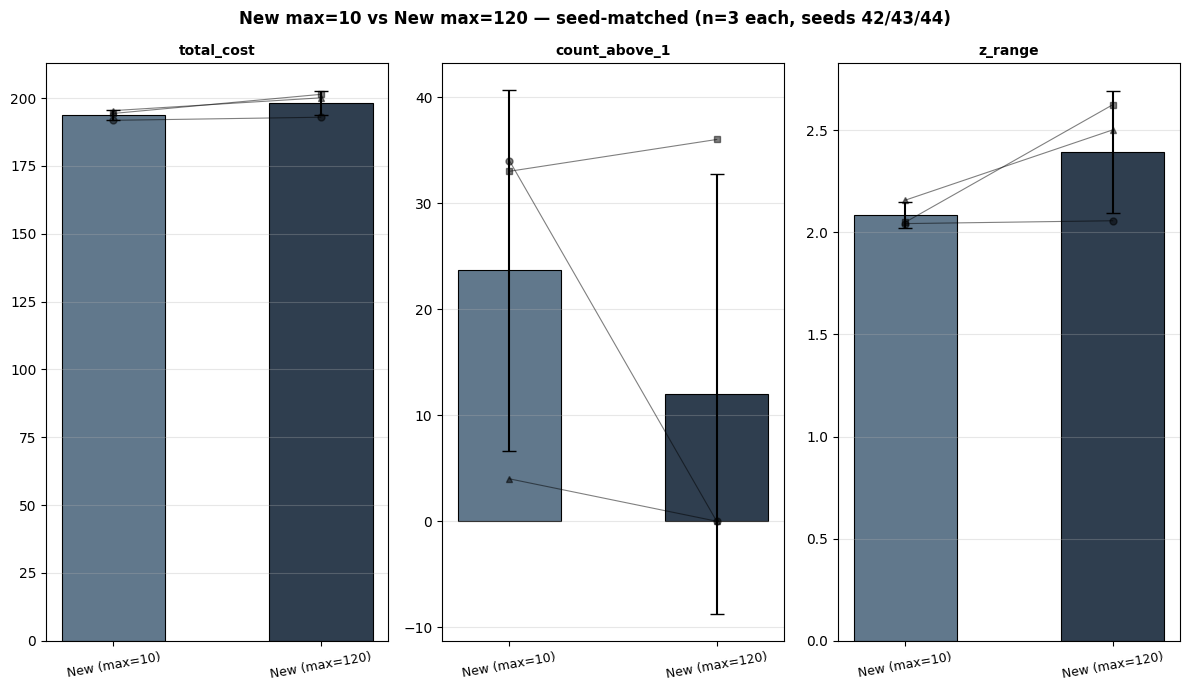


── Key finding: max_uses 10 → 120 has negligible effect (seed-matched, n=3) ──
  Cost delta:        +4.29  (2.2%)
  Over-util delta:   -11.7
  GNN feasibility Δ: +0.0115
  Fitness Δ:         +0.0019
  → Increasing max_uses 10 → 120 gives no meaningful benefit.
     Stock diversity, not max_uses, is the binding constraint for fresh timber.


In [51]:
# 6.3.4  New max=10 vs New max=120 — seed-matched comparison
# New-120: 3 runs (seeds 42/43/44, one replicate each).
# New-10:  6 runs (seeds 42/43/44, two replicates each).
# Seed-matched: pick the best New-10 replicate per seed → 3 vs 3, apples-to-apples.

COND_NEW = ['New (max=10)', 'New (max=120)']

# Best New-10 run per seed (lowest fitness wins when two replicates exist)
df_new10_best = (
    df[df['condition'] == 'New (max=10)']
      .sort_values('best_fitness')
      .groupby('seed', observed=True)
      .first()
      .reset_index()
)
df_new10_best['condition'] = 'New (max=10)'

# New-120: already 1 run per seed
df_new120 = df[df['condition'] == 'New (max=120)'].copy()

# Seed-matched combined frame (6 rows: 3 per condition, same seeds 42/43/44)
df_matched = pd.concat([df_new10_best, df_new120], ignore_index=True)
df_matched['condition'] = pd.Categorical(df_matched['condition'], categories=COND_NEW, ordered=True)

print('── Seed-matched: New max=10 vs New max=120 (n=3 each, seeds 42/43/44) ──')
print('(reuse_rate = 0.0 for both — fresh timber, no RS members)\n')

# Per-seed pivot table
seed_table = df_matched.pivot_table(
    index='seed', columns='condition',
    values=['total_cost', 'count_above_1', 'gnn_feasibility', 'z_range']
)
display(seed_table.round(3))

# Aggregated summary (n=3 each)
new_agg_matched = df_matched.groupby('condition', observed=True)[
    ['total_cost', 'waste_total', 'count_above_1', 'gnn_feasibility', 'z_range', 'best_fitness']
].agg(['mean', 'std']).round(4)
print('\n── Aggregated (seed-matched) ──')
display(new_agg_matched)

# Bar chart with paired seed lines
fig, axes = plt.subplots(1, 3, figsize=config.PLOT_STYLE['figsize_medium'])
fig.suptitle('New max=10 vs New max=120 — seed-matched (n=3 each, seeds 42/43/44)',
             fontsize=12, fontweight='bold')
for ax, metric in zip(axes, ['total_cost', 'count_above_1', 'z_range']):
    means = [df_matched[df_matched['condition'] == c][metric].mean() for c in COND_NEW]
    stds  = [df_matched[df_matched['condition'] == c][metric].std()  for c in COND_NEW]
    ax.bar(COND_NEW, means, yerr=stds, capsize=5,
           color=[COND_COLORS[c] for c in COND_NEW], edgecolor='black', linewidth=0.8, width=0.5)
    # Lines connecting same seed across conditions
    for seed_val in sorted(df_matched['seed'].unique()):
        pts = [df_matched[(df_matched['condition'] == c) & (df_matched['seed'] == seed_val)][metric].values
               for c in COND_NEW]
        if all(len(p) > 0 for p in pts):
            ax.plot([0, 1], [pts[0][0], pts[1][0]],
                    color='black', lw=0.8, alpha=0.5,
                    marker=SEED_MARKERS.get(seed_val, 'o'), markersize=5, zorder=5)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=config.PLOT_STYLE['grid_alpha'])
    ax.tick_params(axis='x', rotation=10, labelsize=9)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_new10_vs_new120.png', dpi=150, bbox_inches='tight')
plt.show()

# Key finding
n10_m  = df_matched[df_matched['condition'] == 'New (max=10)']
n120_m = df_matched[df_matched['condition'] == 'New (max=120)']
cost_delta = n120_m['total_cost'].mean() - n10_m['total_cost'].mean()
cost_pct   = abs(cost_delta / n10_m['total_cost'].mean() * 100)
print('\n── Key finding: max_uses 10 → 120 has negligible effect (seed-matched, n=3) ──')
print(f'  Cost delta:        {cost_delta:+.2f}  ({cost_pct:.1f}%)')
print(f'  Over-util delta:   {n120_m["count_above_1"].mean() - n10_m["count_above_1"].mean():+.1f}')
print(f'  GNN feasibility Δ: {n120_m["gnn_feasibility"].mean() - n10_m["gnn_feasibility"].mean():+.4f}')
print(f'  Fitness Δ:         {n120_m["best_fitness"].mean() - n10_m["best_fitness"].mean():+.4f}')
print(f'  → Increasing max_uses 10 → 120 gives no meaningful benefit.')
print(f'     Stock diversity, not max_uses, is the binding constraint for fresh timber.')


## 6.3 Design outcome — best Stock A run

Geometry, material composition, structural validation, and data exports for the best-performing Stock A design from the final batch. The reference run is selected automatically as the Stock A run with the lowest (best) final fitness.

### 6.3.1 Geometry — RS/NS member provenance

Each of the 120 members is coloured by material state: **orange** = reclaimed stock (RS_), **blue** = new supplement (NS_). Reclaimed members concentrate in the positions where existing RS element lengths best match the force distribution. Top-view projection confirms the near-rectilinear planning footprint is preserved despite bottom-layer irregularity.

In [52]:
# =============================================================================
# 6.3  Select best Stock A run from final batch
# =============================================================================
import csv

FINAL_BATCH = config.GA_DATA_PATH / 'GA_FINAL_BATCH_3PerStock_20260526_GEN250_EVAL_7500'

_sa_dirs = sorted([d for d in FINAL_BATCH.iterdir()
                   if d.is_dir() and d.name.startswith('GA_A')])

_best_f, GA_STEM_63, GA_DIR_63 = None, None, None
for d in _sa_dirs:
    stem = d.name
    hist = pd.read_csv(d / f'{stem}_history.csv')
    f = float(hist['best_ever'].iloc[-1])
    if _best_f is None or f < _best_f:
        _best_f, GA_STEM_63, GA_DIR_63 = f, stem, d

TK_DIR_63 = GA_DIR_63 / 'top_k_designs'

with open(GA_DIR_63 / f'{GA_STEM_63}_run_config.json', encoding='utf-8') as f:
    RC_63 = json.load(f)

_stock_63 = RC_63.get('stock', {})
print(f'Best Stock A run : {GA_STEM_63}')
print(f'Final fitness    : {_best_f:.4f}')
print(f'Stock pool       : {_stock_63.get("n_total","?")} elements  '
      f'(NS={_stock_63.get("n_ns","?")}  RS={_stock_63.get("n_rs","?")})')
print(f'Seed             : {RC_63.get("seed", RC_63.get("ga_config",{}).get("seed","?"))}')

# Load rank-1 vertices + edges
vdf_63 = pd.read_csv(TK_DIR_63 / f'{GA_STEM_63}_top10_vertices.csv')
edf_63 = pd.read_csv(TK_DIR_63 / f'{GA_STEM_63}_top10_edges_assigned.csv')
vdf_63 = vdf_63[vdf_63['rank'] == 1].copy()
edf_63 = edf_63[edf_63['rank'] == 1].copy()

# Load top10 summary rank-1
sum_63  = pd.read_csv(TK_DIR_63 / f'{GA_STEM_63}_top10_summary.csv')
r1_63   = sum_63[sum_63['rank'] == 1].iloc[0]
print(f'Reuse rate       : {float(r1_63["reuse_rate"]):.1%}  (length-weighted)')
print(f'Total cost       : {float(r1_63["total_cost"]):.2f}')
print(f'GNN feasibility  : {float(r1_63["gnn_feasibility"]):.4f}')
print(f'GNN unsafe pred  : {int(r1_63["n_unsafe_members"])} / 120')

# Util violations rank-1
_uv_files = list(TK_DIR_63.glob('*util_violations*'))
_uv = {}
if _uv_files:
    with open(_uv_files[0], newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            row = [v for v in row if v.strip()]
            if not row: continue
            rank = int(row[0])
            if rank != 1: continue
            ca = int(row[1])
            ua = [float(v) for v in row[2:2+ca]]
            cb = int(row[2+ca])
            ub = [float(v) for v in row[3+ca:3+ca+cb]]
            _uv = {'count_above': ca, 'sum_above': sum(ua),
                   'max_above': ua[0] if ua else 0.0,
                   'count_below': cb, 'mean_below': float(sum(ub)/len(ub)) if ub else 0.0}
            break
print(f'Karamba UC>1.0   : {_uv.get("count_above","?")} / 120  '
      f'(sum_excess={_uv.get("sum_above",0):.2f})')
print(f'Karamba UC<1.0   : {_uv.get("count_below","?")} / 120  '
      f'(mean_util={_uv.get("mean_below",0):.3f})')


Best Stock A run : GA_A_20260520_214422_RUN1_GEN250_EVAL7500_F-0_4852
Final fitness    : -0.4852
Stock pool       : 524 elements  (NS=421  RS=103)
Seed             : 42
Reuse rate       : 75.0%  (length-weighted)
Total cost       : 128.66
GNN feasibility  : 0.7611
GNN unsafe pred  : 40 / 120
Karamba UC>1.0   : 0 / 120  (sum_excess=0.00)
Karamba UC<1.0   : 120 / 120  (mean_util=0.024)


RS: 86  NS: 34  reuse 75.0%


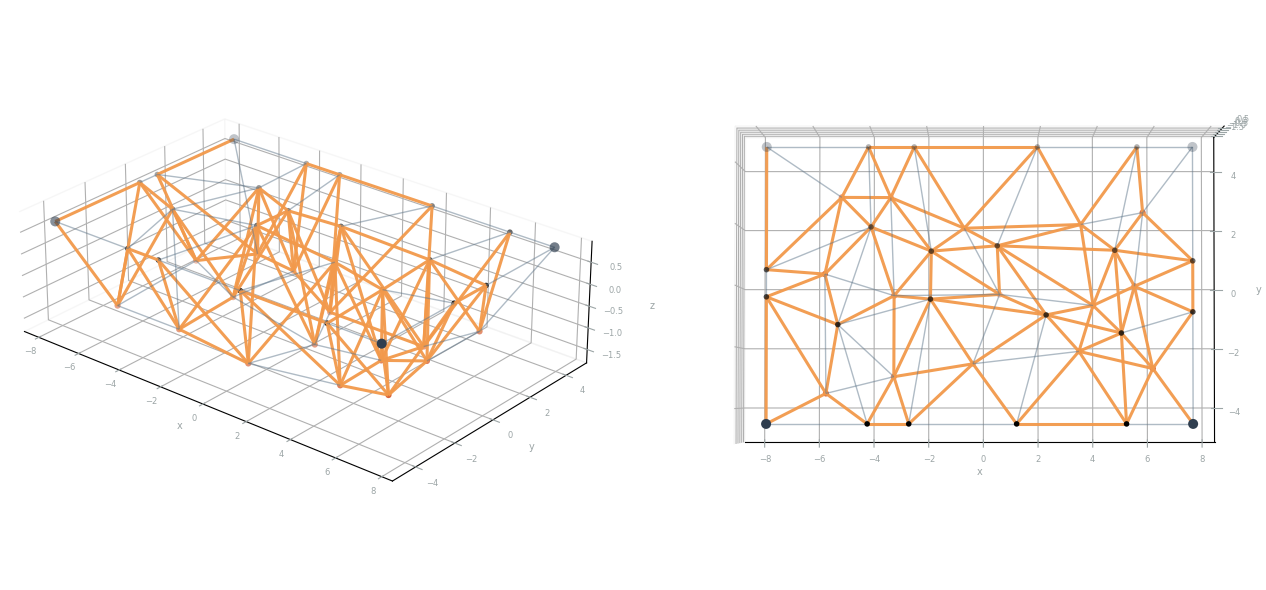

Exported: design_best_SA_vertices.csv  (39 rows)
Exported: design_best_SA_edges.csv     (120 rows)
RS: 86  NS: 34  Total: 120


In [53]:
# =============================================================================
# 6.3.1  RS / NS member provenance — 3D visualisation + plan view
# =============================================================================
from mpl_toolkits.mplot3d.art3d import Line3DCollection

_C_RS   = _PC["RS"]
_C_NS   = _PC["NS"]
_C_SUP  = _PC["upper_node"]
_C_BOT  = _PC["lower_node"]
_C_TOP  = _PC["black"]
_C_MUT  = "#9CA5A6"

vdf_63["vi"] = vdf_63["vertex_index"].apply(
    lambda v: int(str(v)[1:]) if str(v).startswith("v") else int(v))
_vlu = vdf_63.set_index("vi")[["x", "y", "z", "layer", "attribute"]]

v1s   = edf_63["V1"].astype(int).values
v2s   = edf_63["V2"].astype(int).values
valid = np.isin(v1s, _vlu.index) & np.isin(v2s, _vlu.index)
is_rs = edf_63["assigned_timber"].astype(str).str.startswith("RS_").values[valid]

p1   = _vlu.loc[v1s[valid], ["x", "y", "z"]].values
p2   = _vlu.loc[v2s[valid], ["x", "y", "z"]].values
segs = np.stack([p1, p2], axis=1)

rs_count = int(is_rs.sum())
ns_count = int((~is_rs).sum())

print(f"RS: {rs_count}  NS: {ns_count}  reuse {float(r1_63['reuse_rate']):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
fig.patch.set_facecolor("white")

def _style_ax_3d(ax, show_z=True):
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#EEEEEE")
    ax.yaxis.pane.set_edgecolor("#EEEEEE")
    ax.zaxis.pane.set_edgecolor("#EEEEEE")
    ax.grid(True, color="#EEEEEE", linewidth=0.4, alpha=0.5)
    ax.set_xlabel("x", fontsize=7, color=_C_MUT, labelpad=0)
    ax.set_ylabel("y", fontsize=7, color=_C_MUT, labelpad=0)
    ax.set_zlabel("z" if show_z else "", fontsize=7, color=_C_MUT, labelpad=2)
    ax.tick_params(labelsize=6, colors=_C_MUT, pad=1)

_sup = vdf_63["attribute"] == "support"
_bot = (~_sup) & (vdf_63["layer"] == "bottom")
_top = ~_sup & ~_bot
xyz  = vdf_63[["x", "y", "z"]].values

for ax, (elev, azim) in zip(axes, [(26, -50), (88, -90)]):
    ax.add_collection3d(Line3DCollection(segs[is_rs],  color=_C_RS, lw=2.2, alpha=0.95))
    ax.add_collection3d(Line3DCollection(segs[~is_rs], color=_C_NS, lw=1.0, alpha=0.50))
    for mask, col, ms in [(_sup, _C_SUP, 52), (_bot, _C_BOT, 20), (_top, _C_TOP, 16)]:
        ax.scatter3D(xyz[mask, 0], xyz[mask, 1], xyz[mask, 2],
                     c=col, s=ms, zorder=5, edgecolors="none")
    ax.auto_scale_xyz(vdf_63["x"].values, vdf_63["y"].values, vdf_63["z"].values)
    ax.set_box_aspect((1, 0.65, 0.28))
    ax.view_init(elev=elev, azim=azim)
    _style_ax_3d(ax, show_z=(elev < 80))

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_63_geometry.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Data exports ──────────────────────────────────────────────────────────────
_vout = vdf_63.copy()
_vout["material"] = "n/a"
_vout.to_csv(OUTPUT_DIR / "design_best_SA_vertices.csv", index=False)

_eout = edf_63.copy()
_eout["is_reclaimed"] = _eout["assigned_timber"].str.startswith("RS_")
_eout.to_csv(OUTPUT_DIR / "design_best_SA_edges.csv", index=False)

print(f"Exported: design_best_SA_vertices.csv  ({len(_vout)} rows)")
print(f"Exported: design_best_SA_edges.csv     ({len(_eout)} rows)")
print(f"RS: {rs_count}  NS: {ns_count}  Total: {rs_count + ns_count}")


### 6.3.2 Bill of materials

Aggregate RS vs NS counts, volume, and CO₂e penalty. Cross-section inventory lists all unique Width × Depth combinations used. Run the paragraph generator at the end of this section to get filled thesis text.

In [54]:
# =============================================================================
# 6.3.2  Bill of materials — RS vs NS aggregated + cross-section inventory
# =============================================================================

# Load stock CSV
_stock_path = GA_DIR_63 / f'{GA_STEM_63}_stock.csv'
for _opts in [{'sep':';','encoding':'utf-8'},{'sep':',','encoding':'utf-8'},
              {'sep':';','encoding':'latin1'},{'sep':',','encoding':'latin1'}]:
    try:
        _df_stk = pd.read_csv(_stock_path, **_opts)
        if _df_stk.shape[1] > 1: break
    except Exception: pass
_df_stk.columns = _df_stk.columns.str.strip()

# Classify member type from vertex layers
def _vk63(v):
    s = str(v)
    return s if s.startswith('v') else f'v{s}'
_vlyr = vdf_63.set_index('vertex_index')['layer'].to_dict()

def _mtype(row):
    l1 = _vlyr.get(_vk63(row['V1']), '')
    l2 = _vlyr.get(_vk63(row['V2']), '')
    if l1 == l2 == 'top':    return 'Top chord'
    if l1 == l2 == 'bottom': return 'Bottom chord'
    return 'Web / diagonal'

edf_63['member_type'] = edf_63.apply(_mtype, axis=1)
edf_63['material']    = edf_63['assigned_timber'].str[:2]

# Join with stock for length/section/CO2
_cols = ['Member_ID','Length','Width','Depth']
_extra = [c for c in ['CO2_Penalty','EmissionFactor','Transport_Dist'] if c in _df_stk.columns]
merged_63 = edf_63.merge(_df_stk[_cols + _extra],
                          left_on='assigned_timber', right_on='Member_ID', how='left')
merged_63['Length_m']  = merged_63['Length'] / 1000
merged_63['Width_m']   = merged_63['Width']  / 1000
merged_63['Depth_m']   = merged_63['Depth']  / 1000
merged_63['Volume_m3'] = merged_63['Length_m'] * merged_63['Width_m'] * merged_63['Depth_m']

# Aggregate BOM
_agg_cols = {'edge_id': 'count', 'Volume_m3': 'sum', 'Length_m': 'mean'}
if 'CO2_Penalty' in merged_63.columns:
    _agg_cols['CO2_Penalty'] = ['sum','mean']
bom = merged_63.groupby('material').agg(**{
    'Count':      ('edge_id',    'count'),
    'Volume_m3':  ('Volume_m3',  'sum'),
    'Avg_len_m':  ('Length_m',   'mean'),
    **({'CO2e_total': ('CO2_Penalty','sum'), 'CO2e_avg': ('CO2_Penalty','mean')}
       if 'CO2_Penalty' in merged_63.columns else {}),
}).round(3)
bom.loc['Total'] = bom.sum(numeric_only=True)
if 'CO2_Penalty' in merged_63.columns:
    bom.loc['Total','CO2e_avg'] = merged_63['CO2_Penalty'].mean()
bom.loc['Total','Avg_len_m'] = merged_63['Length_m'].mean()

print('=' * 55)
print('BILL OF MATERIALS — aggregate by material state')
print('=' * 55)
display(bom.rename_axis('Material'))

# Cross-section inventory
xs = (merged_63.groupby(['material','Width','Depth'])
               .agg(Count=('edge_id','count'), Total_length_m=('Length_m','sum'))
               .reset_index()
               .sort_values(['material','Count'], ascending=[True,False]))
xs.insert(2, 'Section',
          xs['Width'].astype(int).astype(str) + 'x' + xs['Depth'].astype(int).astype(str) + ' mm')
xs = xs.drop(columns=['Width','Depth'])
print('' + '=' * 55)
print('CROSS-SECTION INVENTORY')
print('=' * 55)
display(xs.set_index(['material','Section']))

# Member-type breakdown
mt_order = ['Top chord','Web / diagonal','Bottom chord']
print('' + '=' * 55)
print('MEMBER TYPE BREAKDOWN')
print('=' * 55)
mt_tbl = merged_63.groupby(['member_type','material']).size().unstack(fill_value=0)
display(mt_tbl.reindex(mt_order))

# Exports
merged_63.to_csv(OUTPUT_DIR / 'design_best_SA_bom.csv', index=False)
xs.to_csv(OUTPUT_DIR / 'design_best_SA_crosssections.csv', index=False)
print(f'\nExported: design_best_SA_bom.csv  ({len(merged_63)} member rows)')
print(f'Exported: design_best_SA_crosssections.csv')


BILL OF MATERIALS — aggregate by material state


,Count,Volume_m3,Avg_len_m,CO2e_total,CO2e_avg
Material,,,,,
NS,34.0,1.750,3.706000,46.438,1.36600
RS,86.0,5.239,3.265000,82.220,0.95600
Total,120.0,6.989,3.390258,128.658,1.07215


CROSS-SECTION INVENTORY


Count  Total_length_m
material Section                          
NS       38x175 mm      10          36.000
         63x200 mm      10          27.000
         75x175 mm      10          51.000
         250x250 mm      2           6.600
         38x100 mm       1           1.200
         100x200 mm      1           4.200
RS       70x190 mm      35         104.764
         110x230 mm     25         112.345
         90x190 mm      19          51.175
         60x170 mm       7          12.547

MEMBER TYPE BREAKDOWN


material,NS,RS
member_type,,
Top chord,20,18
Web / diagonal,3,57
Bottom chord,11,11



Exported: design_best_SA_bom.csv  (120 member rows)
Exported: design_best_SA_crosssections.csv


### 6.3.3 Structural validation — Karamba3D verification

Utilisation check (UC = applied force / capacity) from the `util_violations.csv` export. Members with UC > 1.0 are overstressed. The GNN predicted `n_unsafe_members`; Karamba confirmed `count_above_1`. The paragraph generator below fills in exact values.

In [ ]:
# =============================================================================
# 6.3.3  Structural validation — utilisation summary + paragraph generator
# =============================================================================

# ── Utilisation bar chart ─────────────────────────────────────────────────────
_ca    = _uv.get("count_above", 0)
_cb    = _uv.get("count_below", 0)
_n_gnn = int(r1_63["n_unsafe_members"])
_gnn_f = float(r1_63["gnn_feasibility"])
_err   = abs(_n_gnn - _ca)
_err_pct = _err / 120 * 100

# Palette — from config
C_NS    = "#61788C"
C_RS    = "#F2994B"
C_DARK  = "#2F3E4F"
C_MUTED = "#9CA5A6"
C_LIGHT = "#E8ECEE"
BG      = "#FFFFFF"

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor(BG)

def _style_bar_ax(ax):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_edgecolor("#CCCCCC")
        ax.spines[sp].set_linewidth(0.8)
    ax.tick_params(labelsize=8.5, color="#CCCCCC")
    ax.grid(True, axis="y", color=C_LIGHT, linewidth=0.6, alpha=0.8, zorder=0)

# Panel 1: GNN prediction vs Karamba verification
ax = axes[0]
_style_bar_ax(ax)
bars = ax.bar(
    ["GNN predicted
unsafe", "Karamba
UC > 1.0"],
    [_n_gnn, _ca],
    color=[C_NS, C_RS], alpha=0.88, width=0.45,
    edgecolor="none", zorder=3,
)
ax.set_ylabel("Member count  (of 120)", fontsize=9, color=C_DARK)
ax.tick_params(axis="x", labelsize=9)
for bar, v in zip(bars, [_n_gnn, _ca]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4,
            str(v), ha="center", va="bottom", fontsize=11,
            fontweight="bold", color=C_DARK)

# Panel 2: Karamba utilisation breakdown
ax = axes[1]
_style_bar_ax(ax)
bars = ax.bar(
    ["UC > 1.0
(overloaded)", "UC ≤ 1.0
(safe)"],
    [_ca, _cb],
    color=[C_RS, C_NS], alpha=0.88, width=0.45,
    edgecolor="none", zorder=3,
)
ax.set_ylabel("Member count  (of 120)", fontsize=9, color=C_DARK)
ax.tick_params(axis="x", labelsize=9)
for bar, v in zip(bars, [_ca, _cb]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4,
            str(v), ha="center", va="bottom", fontsize=11,
            fontweight="bold", color=C_DARK)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_633_validation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Paragraph generator ───────────────────────────────────────────────────────
_rr   = float(r1_63["reuse_rate"])
_cost = float(r1_63["total_cost"])
_zr   = float(vertices.get(GA_STEM_63, pd.DataFrame(columns=["z"]))["z"].pipe(
            lambda s: s.max() - s.min() if len(s) else float("nan")))

SyntaxError: unterminated string literal (detected at line 38) (4041956884.py, line 38)